In [ ]:
!pip install transformers torch scikit-learn lime matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 12.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=8ecae7f27201c9a92823d25e038cd310a458a5fb6866d40ebb9efb750c1e4fcb
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
# ╔═══════════════════════════════════════════════════════════════╗
# ║  CELL 1: IMPORTS AND CONFIGURATION                            ║
# ╚═══════════════════════════════════════════════════════════════╝

import os
import re
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datetime import datetime

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    DistilBertTokenizerFast,
    DistilBertModel,
    get_linear_schedule_with_warmup,
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")


class Config:
    DATASET_PATH = "/content/drive/MyDrive/00 MalBert - Internship Project/00_final_dataset_multiview.csv"
    OUTPUT_DIR = "/content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_results"
    MODEL_SAVE_DIR = "/content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_models"

    BERT_MODEL = "distilbert-base-uncased"
    MAX_SEQ_LENGTH = 512
    HIDDEN_DIM = 768
    FUSION_HEADS = 8
    FUSION_LAYERS = 2
    DROPOUT = 0.3

    BATCH_SIZE = 8
    EPOCHS = 7               # Reduced from 15 — sufficient for BERT fine-tuning
    LEARNING_RATE = 3e-5      # Slightly higher to learn faster in fewer epochs
    WEIGHT_DECAY = 0.01
    WARMUP_RATIO = 0.15       # Slightly more warmup to stabilize early training
    GRADIENT_CLIP = 1.0

    BINARY_LOSS_WEIGHT = 0.6
    FAMILY_LOSS_WEIGHT = 0.4

    SEED = 42

    VIEWS = ["PERM", "API", "INTENT", "OPCODE"]
    NUM_VIEWS = 4

    FAMILIES = []
    NUM_FAMILIES = 0


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(Config.SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs(Config.OUTPUT_DIR, exist_ok=True)
os.makedirs(Config.MODEL_SAVE_DIR, exist_ok=True)

print("All imports loaded successfully!")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Epochs: {Config.EPOCHS}, LR: {Config.LEARNING_RATE}, Warmup: {Config.WARMUP_RATIO}")

All imports loaded successfully!
Device: cuda
GPU: Tesla T4
Epochs: 7, LR: 3e-05, Warmup: 0.15


In [ ]:
# ╔═══════════════════════════════════════════════════════════════╗
# ║  CELL 2: MOUNT GOOGLE DRIVE AND VERIFY DATASET                ║
# ╚═══════════════════════════════════════════════════════════════╝

from google.colab import drive
# drive.mount('/content/drive', force_remount=False)
drive.mount('/content/drive', force_remount=True)


# import shutil

# # Remove existing directory
# shutil.rmtree('/content/drive', ignore_errors=True)

# # Mount again
# from google.colab import drive
# drive.mount('/content/drive')



# Verify dataset exists
print("=" * 60)
print("DATASET VERIFICATION")
print("=" * 60)

if os.path.exists(Config.DATASET_PATH):
    size_mb = os.path.getsize(Config.DATASET_PATH) / (1024 * 1024)
    print(f"  Dataset FOUND: {Config.DATASET_PATH}")
    print(f"  Size: {size_mb:.1f} MB")

    # Quick peek
    df_peek = pd.read_csv(Config.DATASET_PATH, encoding="latin-1",
                           on_bad_lines="skip", engine="python", nrows=5)
    print(f"  Columns: {df_peek.columns.tolist()}")
    print(f"  Format: {'Multi-view (separate columns)' if 'PERM' in df_peek.columns else 'Merged text'}")
else:
    print(f"  DATASET NOT FOUND: {Config.DATASET_PATH}")
    print("  Check the path and re-run!")

# Create output directories on Drive (survives runtime reset)
os.makedirs(Config.OUTPUT_DIR, exist_ok=True)
os.makedirs(Config.MODEL_SAVE_DIR, exist_ok=True)
print(f"\n  Results dir: {Config.OUTPUT_DIR}")
print(f"  Model dir:   {Config.MODEL_SAVE_DIR}")

Mounted at /content/drive
DATASET VERIFICATION
  Dataset FOUND: /content/drive/MyDrive/00 MalBert - Internship Project/00_final_dataset_multiview.csv
  Size: 291.3 MB
  Columns: ['file_name', 'family', 'PERM', 'API', 'INTENT', 'OPCODE']
  Format: Multi-view (separate columns)

  Results dir: /content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_results
  Model dir:   /content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_models


In [ ]:
# ╔═══════════════════════════════════════════════════════════════╗
# ║  CELL 3: LOAD AND PREPROCESS DATA                           ║
# ╚═══════════════════════════════════════════════════════════════╝

print("=" * 60)
print("[1/6] Loading and preprocessing data...")
print("=" * 60)

# Load CSV with encoding fix
df = pd.read_csv(Config.DATASET_PATH, encoding="latin-1", on_bad_lines="skip", engine="python")
print(f"Loaded dataset: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Handle merged format (single 'text' column)
if "text" in df.columns and "PERM" not in df.columns:
    print("\nDetected merged format. Splitting 'text' back into views...")

    def split_text_to_views(text):
        if not isinstance(text, str):
            return {"PERM": "", "API": "", "INTENT": "", "OPCODE": ""}
        views = {}
        perm_match = re.search(r"PERM:\s*(.*?)\s*API:", text, re.DOTALL)
        views["PERM"] = perm_match.group(1).strip() if perm_match else ""
        api_match = re.search(r"API:\s*(.*?)\s*INTENT:", text, re.DOTALL)
        views["API"] = api_match.group(1).strip() if api_match else ""
        intent_match = re.search(r"INTENT:\s*(.*?)\s*OPCODE:", text, re.DOTALL)
        views["INTENT"] = intent_match.group(1).strip() if intent_match else ""
        opcode_match = re.search(r"OPCODE:\s*(.*)", text, re.DOTALL)
        views["OPCODE"] = opcode_match.group(1).strip() if opcode_match else ""
        return views

    view_data = df["text"].apply(split_text_to_views).apply(pd.Series)
    df = pd.concat([df.drop(columns=["text"]), view_data], axis=1)
    print("Split complete!")

# Drop unnecessary columns
columns_to_drop = ["apk_size", "permission_count", "api_count", "opcode_count", "intent_count"]
existing_drops = [c for c in columns_to_drop if c in df.columns]
if existing_drops:
    df = df.drop(columns=existing_drops)

# Clean data
df = df.dropna(subset=["family"])
df["family"] = df["family"].replace("Benign3", "Benign")

known_families = ["Banking", "Riskware", "SMS", "Adware", "Benign"]
df = df[df["family"].isin(known_families)].reset_index(drop=True)

# Fill NaN in feature columns
for view in Config.VIEWS:
    if view in df.columns:
        df[view] = df[view].fillna("")
    else:
        df[view] = ""
        print(f"WARNING: Created empty column for missing view: {view}")

# Create labels
df["binary_label"] = (df["family"] != "Benign").astype(int)

label_encoder = LabelEncoder()
df["family_label"] = label_encoder.fit_transform(df["family"])
Config.FAMILIES = list(label_encoder.classes_)
Config.NUM_FAMILIES = len(Config.FAMILIES)

# Print summary
print(f"\nAfter cleaning: {df.shape}")
print(f"Families: {Config.FAMILIES} ({Config.NUM_FAMILIES} classes)")

print(f"\nFamily distribution:")
for family, count in df["family"].value_counts().items():
    binary = 0 if family == "Benign" else 1
    print(f"  {family:12s}: {count:5d}  (binary={binary})")

print(f"\nFeature lengths (words):")
for view in Config.VIEWS:
    lengths = df[view].apply(lambda x: len(x.split()) if x else 0)
    print(f"  {view:8s}:  min={lengths.min():4d}  mean={lengths.mean():7.1f}  max={lengths.max():5d}")

print(f"\nSample data:")
print(df[["family", "binary_label", "family_label"]].head(3))


[1/6] Loading and preprocessing data...
Loaded dataset: (15644, 6)
Columns: ['file_name', 'family', 'PERM', 'API', 'INTENT', 'OPCODE']

After cleaning: (15644, 8)
Families: ['Adware', 'Banking', 'Benign', 'Riskware', 'SMS'] (5 classes)

Family distribution:
  SMS         :  4816  (binary=1)
  Benign      :  3924  (binary=0)
  Riskware    :  2943  (binary=1)
  Banking     :  2463  (binary=1)
  Adware      :  1498  (binary=1)

Feature lengths (words):
  PERM    :  min=   0  mean=   14.5  max=  169
  API     :  min=   0  mean= 1163.4  max=11348
  INTENT  :  min=   0  mean=    7.9  max=  549
  OPCODE  :  min=   0  mean=   67.0  max=  218

Sample data:
   family  binary_label  family_label
0  Adware             1             0
1  Adware             1             0
2  Adware             1             0


In [ ]:
# ╔═══════════════════════════════════════════════════════════════╗
# ║  CELL 4: DATASET CLASS AND DATALOADERS                        ║
# ╚═══════════════════════════════════════════════════════════════╝

print("=" * 60)
print("[2/6] Building datasets and dataloaders...")
print("=" * 60)


class MultiViewMalwareDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=512):
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        item = {}

        for view in Config.VIEWS:
            text = row[view] if isinstance(row[view], str) else ""
            encoding = self.tokenizer(
                text,
                max_length=self.max_length,
                padding="max_length",
                truncation=True,
                return_tensors="pt",
            )
            item[f"{view}_input_ids"] = encoding["input_ids"].squeeze(0)
            item[f"{view}_attention_mask"] = encoding["attention_mask"].squeeze(0)

        item["binary_label"] = torch.tensor(row["binary_label"], dtype=torch.long)
        item["family_label"] = torch.tensor(row["family_label"], dtype=torch.long)
        return item


# Load tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained(Config.BERT_MODEL)

# Splits: 70% train, 10% val, 20% test
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=Config.SEED, stratify=df["family_label"]
)
train_df, val_df = train_test_split(
    train_df, test_size=0.125, random_state=Config.SEED, stratify=train_df["family_label"]
)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Save train/val/test splits to Drive (useful for reproducibility + thesis)
SPLITS_DIR = os.path.join(os.path.dirname(Config.DATASET_PATH), "splits")
os.makedirs(SPLITS_DIR, exist_ok=True)

train_df.to_csv(os.path.join(SPLITS_DIR, "train.csv"), index=False)
val_df.to_csv(os.path.join(SPLITS_DIR, "val.csv"), index=False)
test_df.to_csv(os.path.join(SPLITS_DIR, "test.csv"), index=False)

print(f"Splits saved to: {SPLITS_DIR}")
print(f"  train.csv: {len(train_df)} samples")
print(f"  val.csv:   {len(val_df)} samples")
print(f"  test.csv:  {len(test_df)} samples")

# Create datasets
train_dataset = MultiViewMalwareDataset(train_df, tokenizer, Config.MAX_SEQ_LENGTH)
val_dataset = MultiViewMalwareDataset(val_df, tokenizer, Config.MAX_SEQ_LENGTH)
test_dataset = MultiViewMalwareDataset(test_df, tokenizer, Config.MAX_SEQ_LENGTH)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, num_workers=2, pin_memory=True)

# Quick test
sample = train_dataset[0]
print(f"\nSample check:")
for view in Config.VIEWS:
    print(f"  {view}_input_ids shape: {sample[f'{view}_input_ids'].shape}")
print(f"  binary_label: {sample['binary_label']}")
print(f"  family_label: {sample['family_label']}")
print("\nDataloaders ready!")


[2/6] Building datasets and dataloaders...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train: 10950, Val: 1565, Test: 3129
Splits saved to: /content/drive/MyDrive/00 MalBert - Internship Project/splits
  train.csv: 10950 samples
  val.csv:   1565 samples
  test.csv:  3129 samples

Sample check:
  PERM_input_ids shape: torch.Size([512])
  API_input_ids shape: torch.Size([512])
  INTENT_input_ids shape: torch.Size([512])
  OPCODE_input_ids shape: torch.Size([512])
  binary_label: 0
  family_label: 2

Dataloaders ready!


In [ ]:
# ╔═══════════════════════════════════════════════════════════════╗
# ║  CELL 5: MODEL ARCHITECTURE                                   ║
# ╚═══════════════════════════════════════════════════════════════╝

print("=" * 60)
print("[3/6] Building MalBERT-XAI model...")
print("=" * 60)


class CrossAttentionFusion(nn.Module):
    """
    Cross-attention module: each view attends to all other views.
    This captures inter-view correlations (e.g., suspicious permission
    + suspicious API call = higher malware probability).
    """

    def __init__(self, hidden_dim, num_heads, num_layers, dropout=0.1):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.view_position = nn.Parameter(torch.randn(1, Config.NUM_VIEWS, hidden_dim) * 0.02)
        self.attention_pool = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 4),
            nn.Tanh(),
            nn.Linear(hidden_dim // 4, 1),
        )
        self.layer_norm = nn.LayerNorm(hidden_dim)

    def forward(self, view_embeddings, return_attention=False):
        x = view_embeddings + self.view_position
        x = self.transformer(x)
        attn_scores = self.attention_pool(x)
        attn_weights = F.softmax(attn_scores, dim=1)
        fused = (x * attn_weights).sum(dim=1)
        fused = self.layer_norm(fused)
        if return_attention:
            return fused, attn_weights.squeeze(-1)
        return fused


class MalBERTXAI(nn.Module):
    """
    Multi-View Transformer with Cross-Attention Fusion
    and Hierarchical Classification for Android Malware Detection.

    4x DistilBERT (shared) -> View Projections -> Cross-Attention Fusion
    -> Binary Head (Malware/Benign) + Family Head (multi-class)
    """

    def __init__(self, config):
        super().__init__()
        # Shared DistilBERT backbone
        self.bert = DistilBertModel.from_pretrained(config.BERT_MODEL)

        # View-specific projection layers
        self.view_projections = nn.ModuleDict({
            view: nn.Sequential(
                nn.Linear(config.HIDDEN_DIM, config.HIDDEN_DIM),
                nn.LayerNorm(config.HIDDEN_DIM),
                nn.GELU(),
                nn.Dropout(config.DROPOUT),
            )
            for view in config.VIEWS
        })

        # Cross-attention fusion
        self.fusion = CrossAttentionFusion(
            hidden_dim=config.HIDDEN_DIM,
            num_heads=config.FUSION_HEADS,
            num_layers=config.FUSION_LAYERS,
            dropout=config.DROPOUT,
        )

        # Binary classification head (Malware vs Benign)
        self.binary_classifier = nn.Sequential(
            nn.Linear(config.HIDDEN_DIM, config.HIDDEN_DIM // 2),
            nn.GELU(),
            nn.Dropout(config.DROPOUT),
            nn.Linear(config.HIDDEN_DIM // 2, 2),
        )

        # Family classification head (multi-class)
        self.family_classifier = nn.Sequential(
            nn.Linear(config.HIDDEN_DIM, config.HIDDEN_DIM // 2),
            nn.GELU(),
            nn.Dropout(config.DROPOUT),
            nn.Linear(config.HIDDEN_DIM // 2, config.NUM_FAMILIES),
        )

    def encode_view(self, input_ids, attention_mask, view_name):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        projected = self.view_projections[view_name](cls_embedding)
        return projected

    def forward(self, batch, return_attention=False):
        view_embeddings = []
        for view in Config.VIEWS:
            input_ids = batch[f"{view}_input_ids"]
            attention_mask = batch[f"{view}_attention_mask"]
            emb = self.encode_view(input_ids, attention_mask, view)
            view_embeddings.append(emb)

        stacked = torch.stack(view_embeddings, dim=1)

        if return_attention:
            fused, attn_weights = self.fusion(stacked, return_attention=True)
        else:
            fused = self.fusion(stacked)
            attn_weights = None

        binary_logits = self.binary_classifier(fused)
        family_logits = self.family_classifier(fused)

        if return_attention:
            return binary_logits, family_logits, attn_weights
        return binary_logits, family_logits


# Build model
model = MalBERTXAI(Config).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("Model built successfully!")


[3/6] Building MalBERT-XAI model...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters:     83,652,872
Trainable parameters: 83,652,872
Model built successfully!


In [ ]:
# ╔═══════════════════════════════════════════════════════════════╗
# ║  CELL 6: TRAINING                                             ║
# ╚═══════════════════════════════════════════════════════════════╝

print("=" * 60)
print("[4/6] Training...")
print("=" * 60)
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# Class weights for imbalanced data
binary_counts = train_df["binary_label"].value_counts()
total = len(train_df)
binary_weights = torch.tensor(
    [total / (2 * binary_counts.get(0, 1)), total / (2 * binary_counts.get(1, 1))],
    dtype=torch.float32,
).to(device)

binary_criterion = nn.CrossEntropyLoss(weight=binary_weights)

# Family class weights for imbalanced data
family_counts = train_df["family_label"].value_counts()
family_weight_list = [total / (Config.NUM_FAMILIES * family_counts.get(i, 1))
                      for i in range(Config.NUM_FAMILIES)]
family_weights_tensor = torch.tensor(family_weight_list, dtype=torch.float32).to(device)
family_criterion = nn.CrossEntropyLoss(weight=family_weights_tensor)
print(f"Family weights: {dict(zip(Config.FAMILIES, [f'{w:.2f}' for w in family_weight_list]))}")

# Optimizer with differential learning rates
bert_params = list(model.bert.parameters())
head_params = (
    list(model.view_projections.parameters())
    + list(model.fusion.parameters())
    + list(model.binary_classifier.parameters())
    + list(model.family_classifier.parameters())
)

optimizer = AdamW(
    [
        {"params": bert_params, "lr": Config.LEARNING_RATE},
        {"params": head_params, "lr": Config.LEARNING_RATE * 5},
    ],
    weight_decay=Config.WEIGHT_DECAY,
)

num_training_steps = len(train_loader) * Config.EPOCHS
num_warmup_steps = int(num_training_steps * Config.WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=num_warmup_steps, num_training_steps=num_training_steps
)

# Training history
history = {
    "train_loss": [], "val_loss": [],
    "train_binary_acc": [], "val_binary_acc": [],
    "train_family_acc": [], "val_family_acc": [],
    "val_binary_f1": [], "val_family_f1": [],
}

best_val_f1 = 0
patience = 2
patience_counter = 0

for epoch in range(Config.EPOCHS):

    # ── TRAIN ──
    model.train()
    total_loss = 0
    train_bin_preds, train_bin_labels = [], []
    train_fam_preds, train_fam_labels = [], []

    for batch_idx, batch in enumerate(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()
        binary_logits, family_logits = model(batch)

        loss_binary = binary_criterion(binary_logits, batch["binary_label"])
        loss_family = family_criterion(family_logits, batch["family_label"])
        loss = Config.BINARY_LOSS_WEIGHT * loss_binary + Config.FAMILY_LOSS_WEIGHT * loss_family

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), Config.GRADIENT_CLIP)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        train_bin_preds.extend(binary_logits.argmax(dim=1).cpu().tolist())
        train_bin_labels.extend(batch["binary_label"].cpu().tolist())
        train_fam_preds.extend(family_logits.argmax(dim=1).cpu().tolist())
        train_fam_labels.extend(batch["family_label"].cpu().tolist())

        if (batch_idx + 1) % 20 == 0:
            print(f"  Epoch {epoch+1} | Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

    train_loss = total_loss / len(train_loader)
    train_binary_acc = accuracy_score(train_bin_labels, train_bin_preds)
    train_family_acc = accuracy_score(train_fam_labels, train_fam_preds)

    # ── VALIDATE ──
    model.eval()
    val_loss = 0
    val_bin_preds, val_bin_labels = [], []
    val_fam_preds, val_fam_labels = [], []

    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            binary_logits, family_logits = model(batch)

            loss_binary = binary_criterion(binary_logits, batch["binary_label"])
            loss_family = family_criterion(family_logits, batch["family_label"])
            loss = Config.BINARY_LOSS_WEIGHT * loss_binary + Config.FAMILY_LOSS_WEIGHT * loss_family

            val_loss += loss.item()
            val_bin_preds.extend(binary_logits.argmax(dim=1).cpu().tolist())
            val_bin_labels.extend(batch["binary_label"].cpu().tolist())
            val_fam_preds.extend(family_logits.argmax(dim=1).cpu().tolist())
            val_fam_labels.extend(batch["family_label"].cpu().tolist())

    val_loss = val_loss / len(val_loader)
    val_binary_acc = accuracy_score(val_bin_labels, val_bin_preds)
    val_family_acc = accuracy_score(val_fam_labels, val_fam_preds)
    val_binary_f1 = f1_score(val_bin_labels, val_bin_preds, average="weighted")
    val_family_f1 = f1_score(val_fam_labels, val_fam_preds, average="weighted")

    # Store history
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_binary_acc"].append(train_binary_acc)
    history["val_binary_acc"].append(val_binary_acc)
    history["train_family_acc"].append(train_family_acc)
    history["val_family_acc"].append(val_family_acc)
    history["val_binary_f1"].append(val_binary_f1)
    history["val_family_f1"].append(val_family_f1)

    # Print epoch summary
    print(
        f"\n>>> Epoch {epoch+1}/{Config.EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Bin Acc: {val_binary_acc:.4f} | Fam Acc: {val_family_acc:.4f} | "
        f"Bin F1: {val_binary_f1:.4f} | Fam F1: {val_family_f1:.4f}\n"
    )

    # Early stopping
    combined_f1 = Config.BINARY_LOSS_WEIGHT * val_binary_f1 + Config.FAMILY_LOSS_WEIGHT * val_family_f1
    if combined_f1 > best_val_f1:
        best_val_f1 = combined_f1
        patience_counter = 0
        torch.save(model.state_dict(), os.path.join(Config.MODEL_SAVE_DIR, "best_model.pt"))
        print(f"  -> Saved best model (combined F1: {combined_f1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

# Load best model
model.load_state_dict(torch.load(os.path.join(Config.MODEL_SAVE_DIR, "best_model.pt")))
print(f"\nTraining complete! Best model loaded.")
print(f"Finished at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


[4/6] Training...
Timestamp: 2026-04-14 18:39:44
Family weights: {'Adware': '2.09', 'Banking': '1.27', 'Benign': '0.80', 'Riskware': '1.06', 'SMS': '0.65'}
  Epoch 1 | Batch 20/1369 | Loss: 1.1172
  Epoch 1 | Batch 40/1369 | Loss: 1.0282
  Epoch 1 | Batch 60/1369 | Loss: 1.0894
  Epoch 1 | Batch 80/1369 | Loss: 0.9837
  Epoch 1 | Batch 100/1369 | Loss: 1.0663
  Epoch 1 | Batch 120/1369 | Loss: 1.0265
  Epoch 1 | Batch 140/1369 | Loss: 0.8444
  Epoch 1 | Batch 160/1369 | Loss: 0.7804
  Epoch 1 | Batch 180/1369 | Loss: 0.5244
  Epoch 1 | Batch 200/1369 | Loss: 0.7418
  Epoch 1 | Batch 220/1369 | Loss: 0.4755
  Epoch 1 | Batch 240/1369 | Loss: 0.5887
  Epoch 1 | Batch 260/1369 | Loss: 0.4752
  Epoch 1 | Batch 280/1369 | Loss: 0.4763
  Epoch 1 | Batch 300/1369 | Loss: 0.2082
  Epoch 1 | Batch 320/1369 | Loss: 0.1031
  Epoch 1 | Batch 340/1369 | Loss: 0.4577
  Epoch 1 | Batch 360/1369 | Loss: 0.1514
  Epoch 1 | Batch 380/1369 | Loss: 0.1892
  Epoch 1 | Batch 400/1369 | Loss: 0.3366
  Epoch 

In [ ]:
# ╔═══════════════════════════════════════════════════════════════╗
# ║  CELL 7: FINAL EVALUATION ON TEST SET                         ║
# ╚═══════════════════════════════════════════════════════════════╝

print("=" * 60)
print("[5/6] Final evaluation on test set...")
print("=" * 60)

model.eval()
test_bin_preds, test_bin_labels, test_bin_probs = [], [], []
test_fam_preds, test_fam_labels, test_fam_probs = [], [], []
all_attn_weights = []

with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        binary_logits, family_logits, attn_weights = model(batch, return_attention=True)

        test_bin_preds.extend(binary_logits.argmax(dim=1).cpu().tolist())
        test_bin_labels.extend(batch["binary_label"].cpu().tolist())
        test_bin_probs.extend(F.softmax(binary_logits, dim=1).cpu().numpy())

        test_fam_preds.extend(family_logits.argmax(dim=1).cpu().tolist())
        test_fam_labels.extend(batch["family_label"].cpu().tolist())
        test_fam_probs.extend(F.softmax(family_logits, dim=1).cpu().numpy())

        all_attn_weights.extend(attn_weights.cpu().numpy())

test_bin_probs = np.array(test_bin_probs)
test_fam_probs = np.array(test_fam_probs)
all_attn_weights = np.array(all_attn_weights)

# ── Binary Classification Report ──
print("\n" + "=" * 60)
print("BINARY CLASSIFICATION REPORT (Malware vs Benign)")
print("=" * 60)
print(classification_report(
    test_bin_labels, test_bin_preds,
    target_names=["Benign", "Malware"], digits=4,
))

# ── Family Classification Report ──
print("\n" + "=" * 60)
print("FAMILY CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(
    test_fam_labels, test_fam_preds,
    target_names=label_encoder.classes_, digits=4,
))

# ── ROC-AUC ──
try:
    binary_auc = roc_auc_score(test_bin_labels, test_bin_probs[:, 1])
    print(f"Binary ROC-AUC: {binary_auc:.4f}")
except Exception as e:
    binary_auc = 0.0
    print(f"Could not compute AUC: {e}")

# ── Summary ──
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Binary Accuracy:  {accuracy_score(test_bin_labels, test_bin_preds):.4f}")
print(f"Binary F1:        {f1_score(test_bin_labels, test_bin_preds, average='weighted'):.4f}")
print(f"Binary AUC:       {binary_auc:.4f}")
print(f"Family Accuracy:  {accuracy_score(test_fam_labels, test_fam_preds):.4f}")
print(f"Family F1:        {f1_score(test_fam_labels, test_fam_preds, average='weighted'):.4f}")


[5/6] Final evaluation on test set...

BINARY CLASSIFICATION REPORT (Malware vs Benign)
              precision    recall  f1-score   support

      Benign     0.9569    0.9898    0.9731       785
     Malware     0.9965    0.9851    0.9908      2344

    accuracy                         0.9863      3129
   macro avg     0.9767    0.9874    0.9819      3129
weighted avg     0.9866    0.9863    0.9863      3129


FAMILY CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Adware     0.9251    0.9498    0.9373       299
     Banking     0.9779    0.8986    0.9366       493
      Benign     0.9604    0.9885    0.9743       785
    Riskware     0.9474    0.9474    0.9474       589
         SMS     0.9856    0.9948    0.9902       963

    accuracy                         0.9648      3129
   macro avg     0.9593    0.9558    0.9571      3129
weighted avg     0.9651    0.9648    0.9646      3129

Binary ROC-AUC: 0.9989

SUMMARY
Binary Accuracy:  0.9863
Binary F1

[6/6] Generating plots...


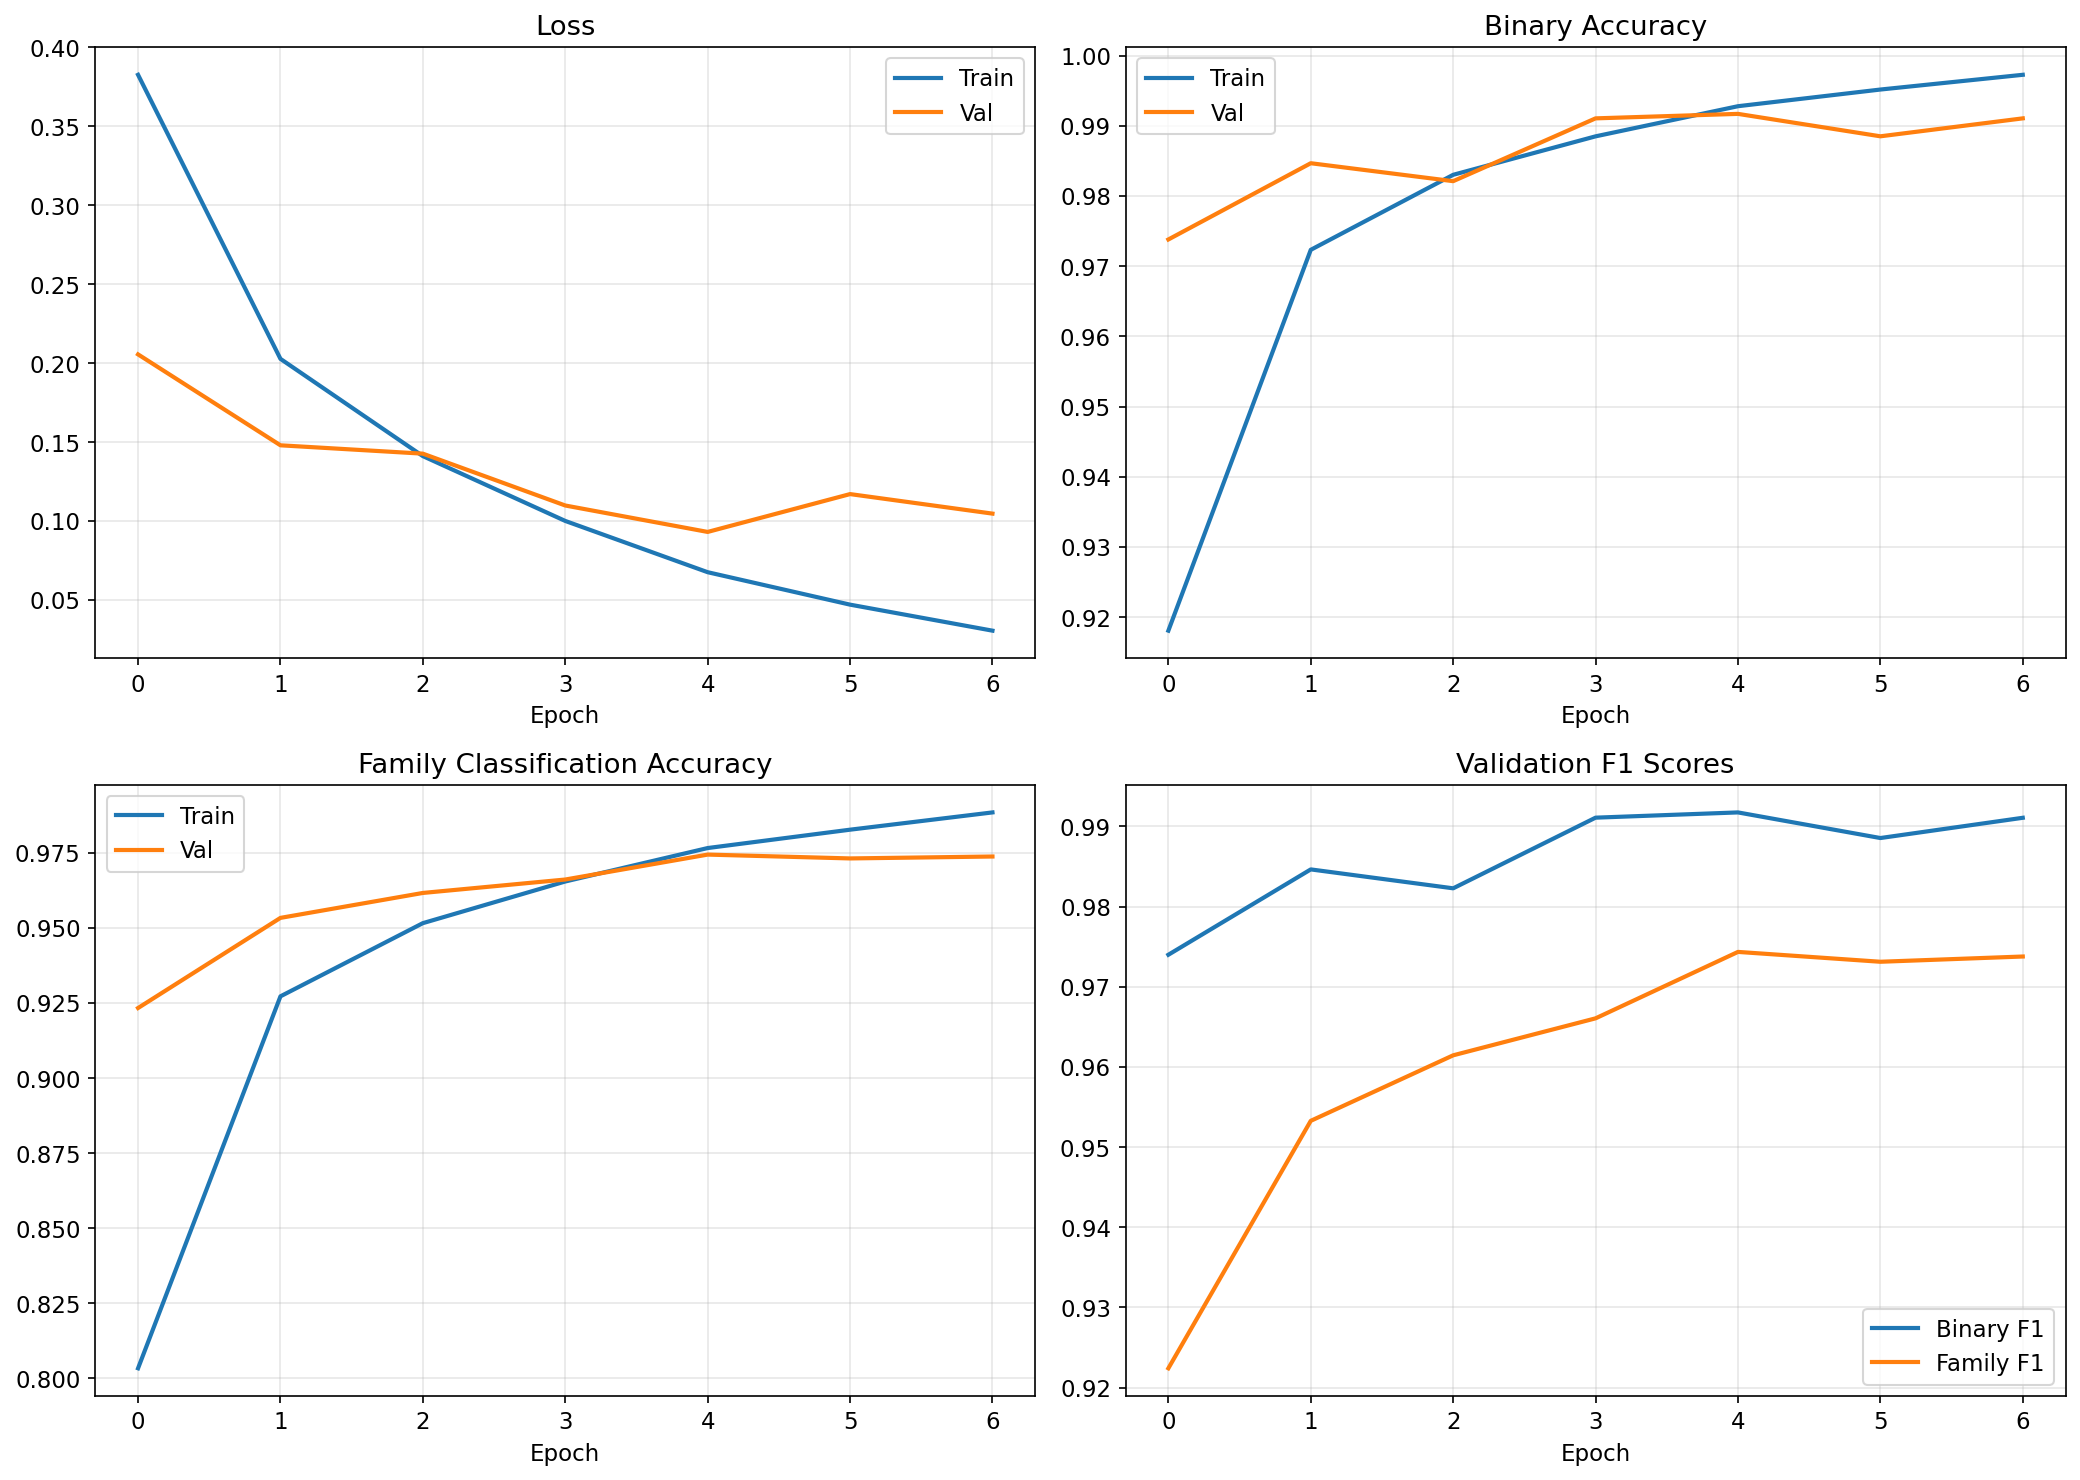

Saved: training_curves.png


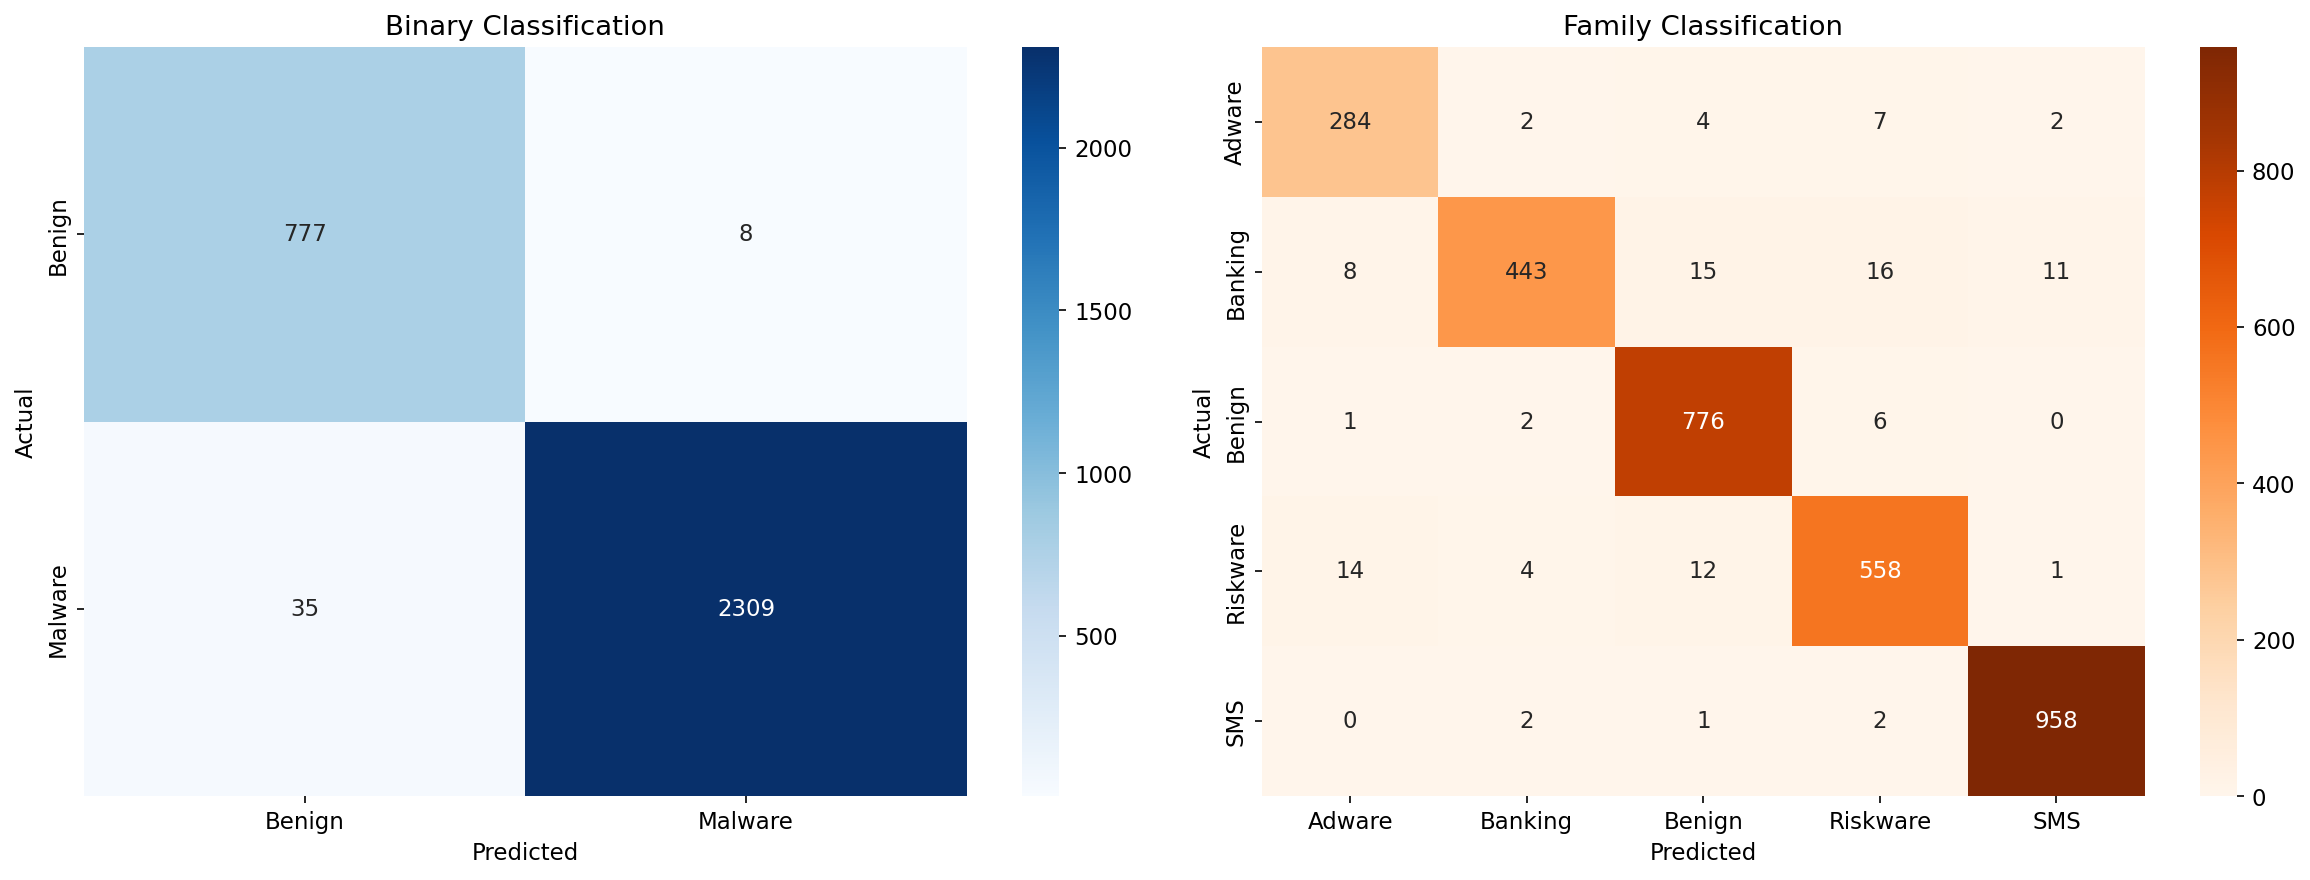

Saved: confusion_matrices.png


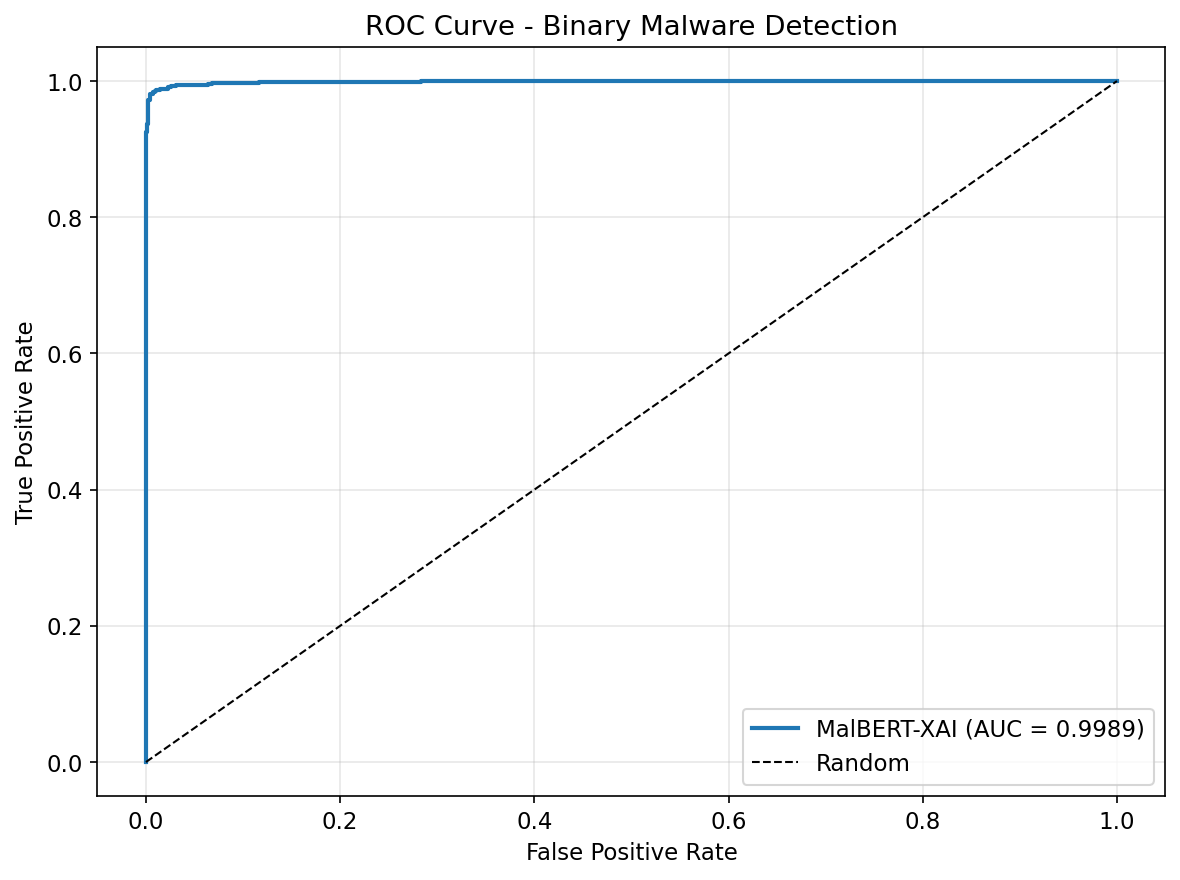

Saved: roc_curve.png


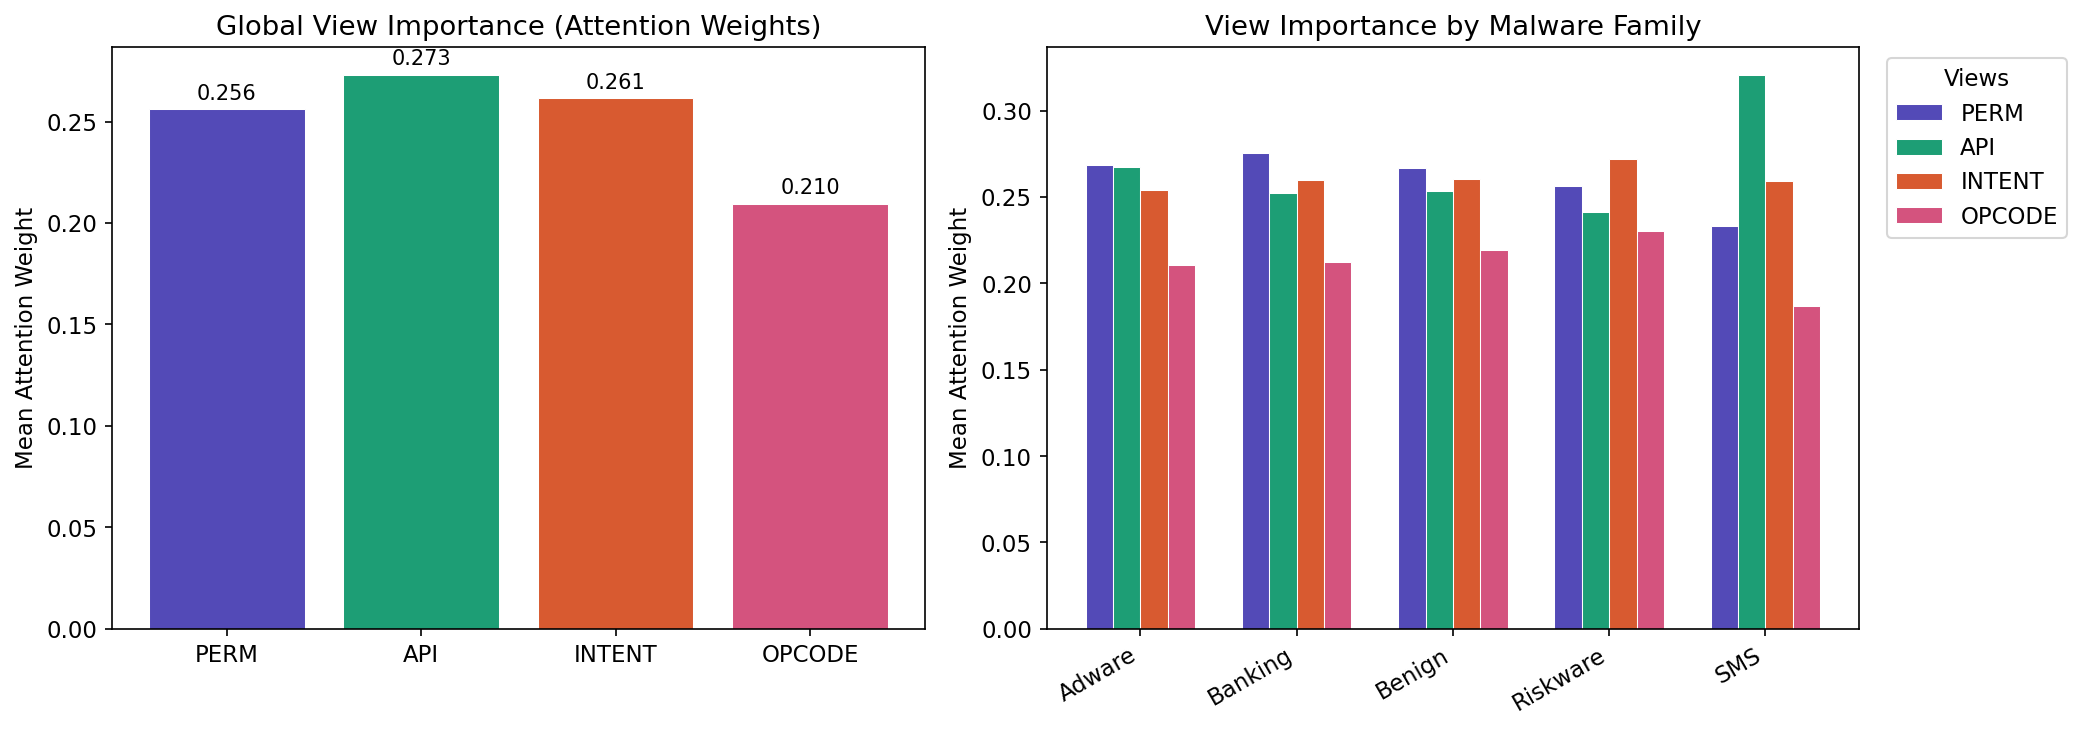

Saved: view_attention_analysis.png

All plots saved to: /content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_results


In [ ]:
# ╔═══════════════════════════════════════════════════════════════╗
# ║  CELL 8: GENERATE ALL PLOTS FOR THE PAPER                     ║
# ╚═══════════════════════════════════════════════════════════════╝

print("=" * 60)
print("[6/6] Generating plots...")
print("=" * 60)

plt.rcParams.update({"figure.dpi": 150, "font.size": 11})

# ── Plot 1: Training Curves ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(history["train_loss"], label="Train", linewidth=2)
axes[0, 0].plot(history["val_loss"], label="Val", linewidth=2)
axes[0, 0].set_title("Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(history["train_binary_acc"], label="Train", linewidth=2)
axes[0, 1].plot(history["val_binary_acc"], label="Val", linewidth=2)
axes[0, 1].set_title("Binary Accuracy")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(history["train_family_acc"], label="Train", linewidth=2)
axes[1, 0].plot(history["val_family_acc"], label="Val", linewidth=2)
axes[1, 0].set_title("Family Classification Accuracy")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(history["val_binary_f1"], label="Binary F1", linewidth=2)
axes[1, 1].plot(history["val_family_f1"], label="Family F1", linewidth=2)
axes[1, 1].set_title("Validation F1 Scores")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(Config.OUTPUT_DIR, "training_curves.png"), bbox_inches="tight")
plt.show()
print("Saved: training_curves.png")

# ── Plot 2: Confusion Matrices ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_binary = confusion_matrix(test_bin_labels, test_bin_preds)
sns.heatmap(cm_binary, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Benign", "Malware"], yticklabels=["Benign", "Malware"])
axes[0].set_title("Binary Classification")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

cm_family = confusion_matrix(test_fam_labels, test_fam_preds)
sns.heatmap(cm_family, annot=True, fmt="d", cmap="Oranges", ax=axes[1],
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
axes[1].set_title("Family Classification")
axes[1].set_ylabel("Actual")
axes[1].set_xlabel("Predicted")

plt.tight_layout()
plt.savefig(os.path.join(Config.OUTPUT_DIR, "confusion_matrices.png"), bbox_inches="tight")
plt.show()
print("Saved: confusion_matrices.png")

# ── Plot 3: ROC Curve ──
if binary_auc > 0:
    fpr, tpr, _ = roc_curve(test_bin_labels, test_bin_probs[:, 1])
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, linewidth=2, label=f"MalBERT-XAI (AUC = {binary_auc:.4f})")
    plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - Binary Malware Detection")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(Config.OUTPUT_DIR, "roc_curve.png"), bbox_inches="tight")
    plt.show()
    print("Saved: roc_curve.png")

# ── Plot 4: View Attention Analysis (KEY NOVELTY FIGURE) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mean_attn = all_attn_weights.mean(axis=0)
colors = ["#534AB7", "#1D9E75", "#D85A30", "#D4537E"]

axes[0].bar(Config.VIEWS, mean_attn, color=colors, edgecolor="white", linewidth=0.5)
axes[0].set_title("Global View Importance (Attention Weights)")
axes[0].set_ylabel("Mean Attention Weight")
for i, v in enumerate(mean_attn):
    axes[0].text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=10)

family_attn = {}
for fam_id in range(Config.NUM_FAMILIES):
    mask = np.array(test_fam_labels) == fam_id
    if mask.sum() > 0:
        family_name = label_encoder.inverse_transform([fam_id])[0]
        family_attn[family_name] = all_attn_weights[mask].mean(axis=0)

family_df = pd.DataFrame(family_attn, index=Config.VIEWS).T
family_df.plot(kind="bar", ax=axes[1], width=0.7, color=colors, edgecolor="white", linewidth=0.5)
axes[1].set_title("View Importance by Malware Family")
axes[1].set_ylabel("Mean Attention Weight")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha="right")
axes[1].legend(title="Views", bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.savefig(os.path.join(Config.OUTPUT_DIR, "view_attention_analysis.png"), bbox_inches="tight")
plt.show()
print("Saved: view_attention_analysis.png")

print(f"\nAll plots saved to: {Config.OUTPUT_DIR}")


Running LIME Explainability...

  Explaining Adware sample (view: API, 272 tokens)...


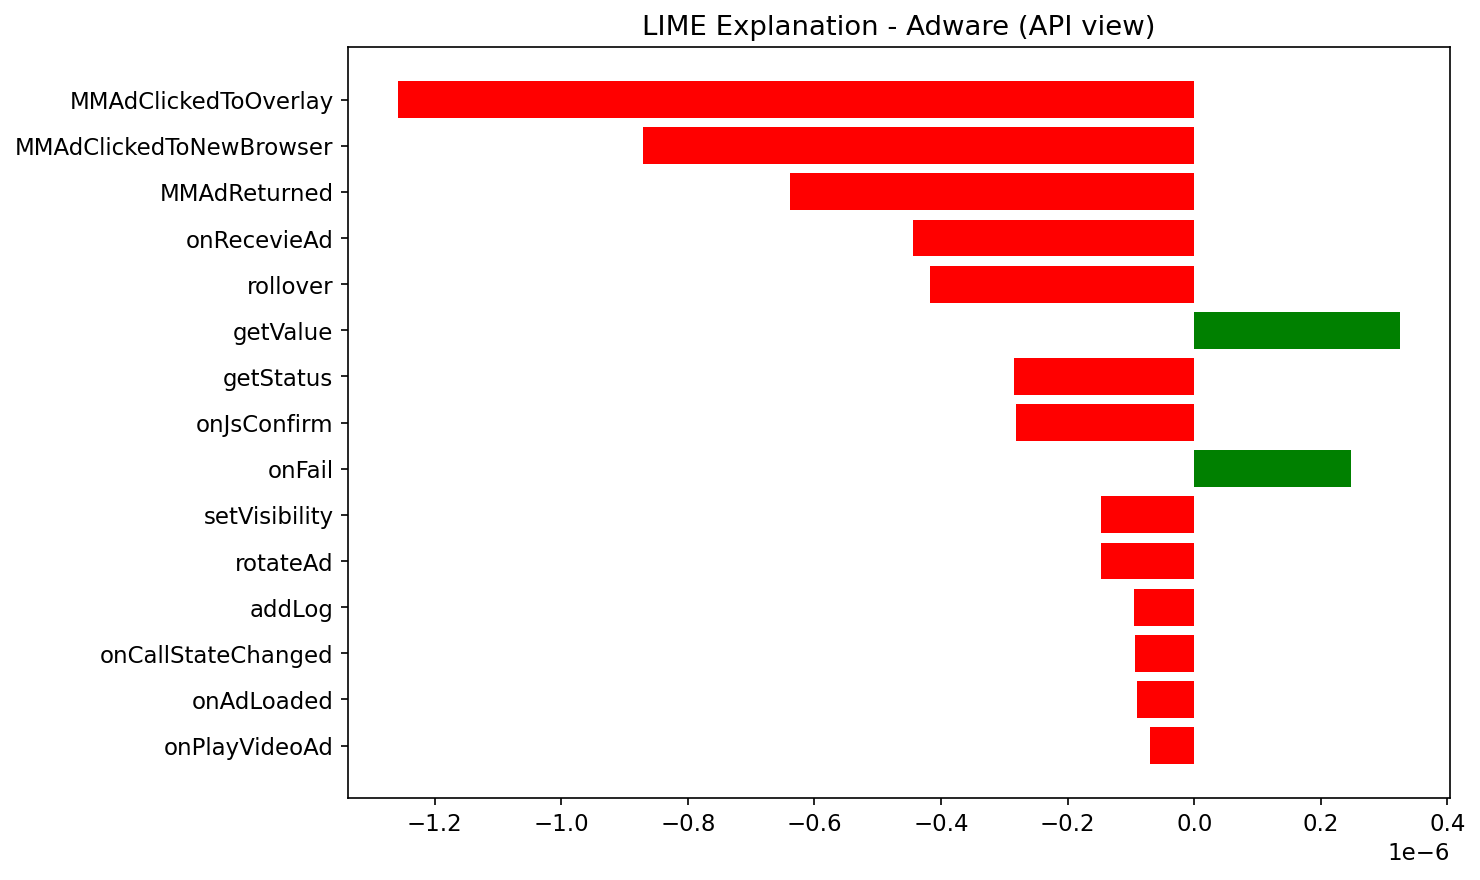

  Top contributing tokens in API:
    MMAdClickedToOverlay           -> benign (-0.0000)
    MMAdClickedToNewBrowser        -> benign (-0.0000)
    MMAdReturned                   -> benign (-0.0000)
    onRecevieAd                    -> benign (-0.0000)
    rollover                       -> benign (-0.0000)
    getValue                       -> malware (+0.0000)
    getStatus                      -> benign (-0.0000)
    onJsConfirm                    -> benign (-0.0000)
    onFail                         -> malware (+0.0000)
    setVisibility                  -> benign (-0.0000)

  Explaining Banking sample (view: OPCODE, 32 tokens)...


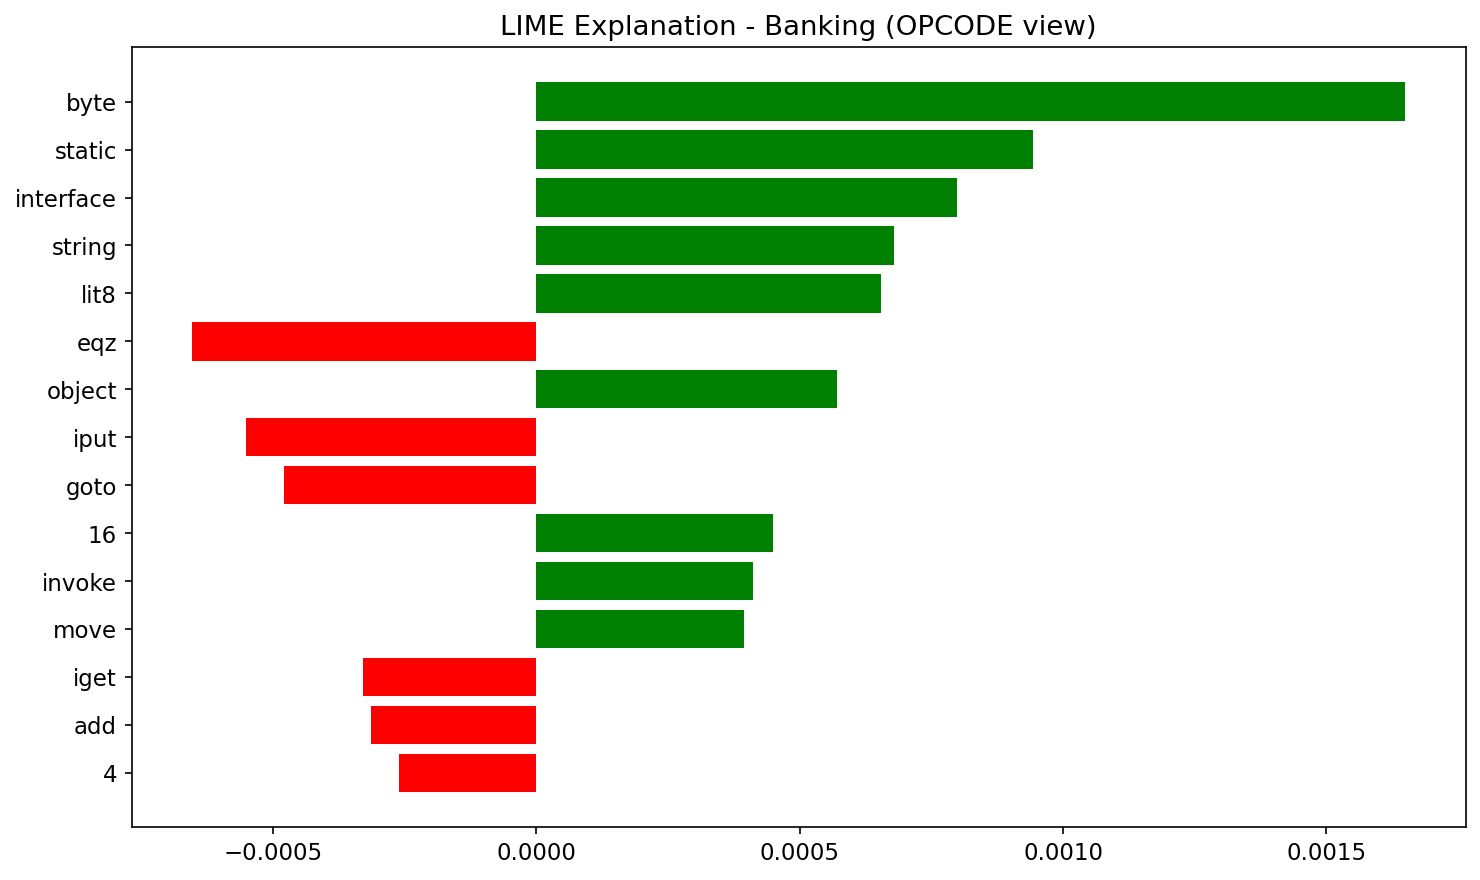

  Top contributing tokens in OPCODE:
    byte                           -> malware (+0.0016)
    static                         -> malware (+0.0009)
    interface                      -> malware (+0.0008)
    string                         -> malware (+0.0007)
    lit8                           -> malware (+0.0007)
    eqz                            -> benign (-0.0007)
    object                         -> malware (+0.0006)
    iput                           -> benign (-0.0006)
    goto                           -> benign (-0.0005)
    16                             -> malware (+0.0004)

  Explaining Benign sample (view: API, 309 tokens)...


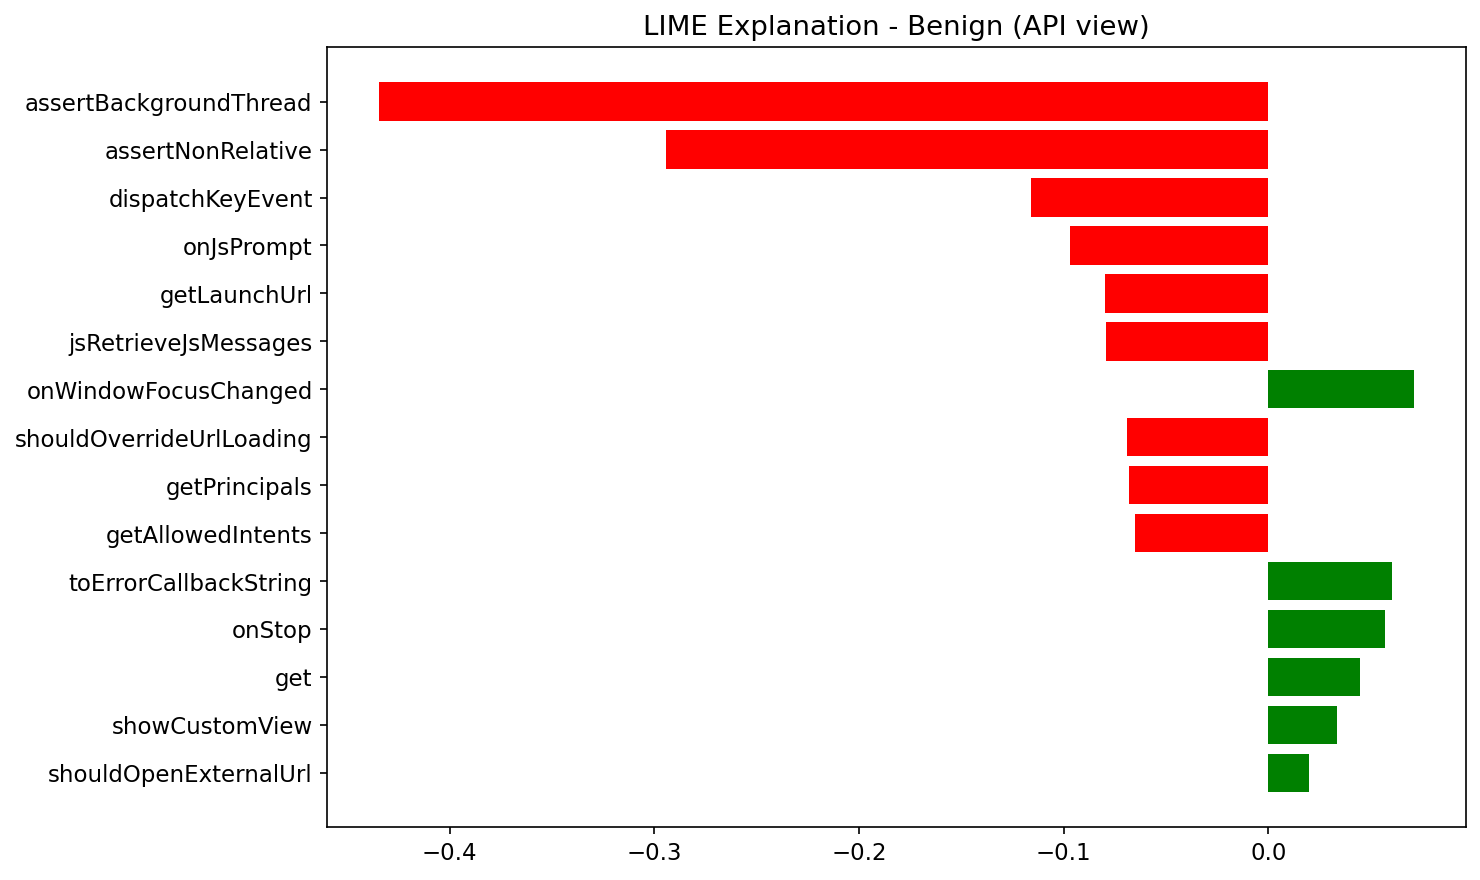

  Top contributing tokens in API:
    assertBackgroundThread         -> benign (-0.4346)
    assertNonRelative              -> benign (-0.2943)
    dispatchKeyEvent               -> benign (-0.1158)
    onJsPrompt                     -> benign (-0.0970)
    getLaunchUrl                   -> benign (-0.0799)
    jsRetrieveJsMessages           -> benign (-0.0792)
    onWindowFocusChanged           -> malware (+0.0711)
    shouldOverrideUrlLoading       -> benign (-0.0690)
    getPrincipals                  -> benign (-0.0682)
    getAllowedIntents              -> benign (-0.0651)

  Explaining Riskware sample (view: OPCODE, 74 tokens)...


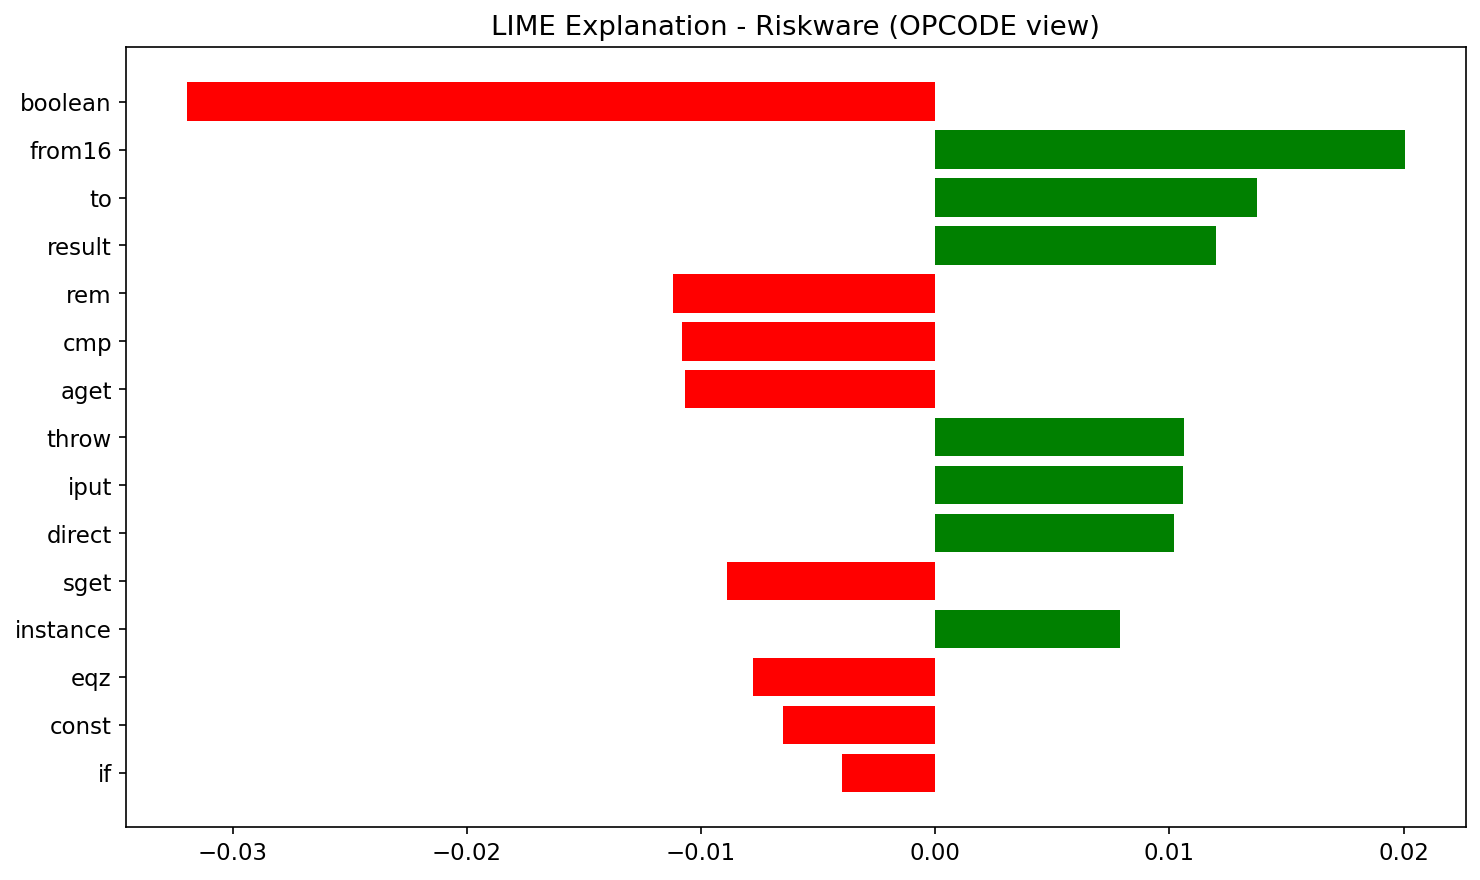

  Top contributing tokens in OPCODE:
    boolean                        -> benign (-0.0319)
    from16                         -> malware (+0.0200)
    to                             -> malware (+0.0137)
    result                         -> malware (+0.0120)
    rem                            -> benign (-0.0112)
    cmp                            -> benign (-0.0108)
    aget                           -> benign (-0.0107)
    throw                          -> malware (+0.0106)
    iput                           -> malware (+0.0106)
    direct                         -> malware (+0.0102)

  Explaining SMS sample (view: API, 149 tokens)...


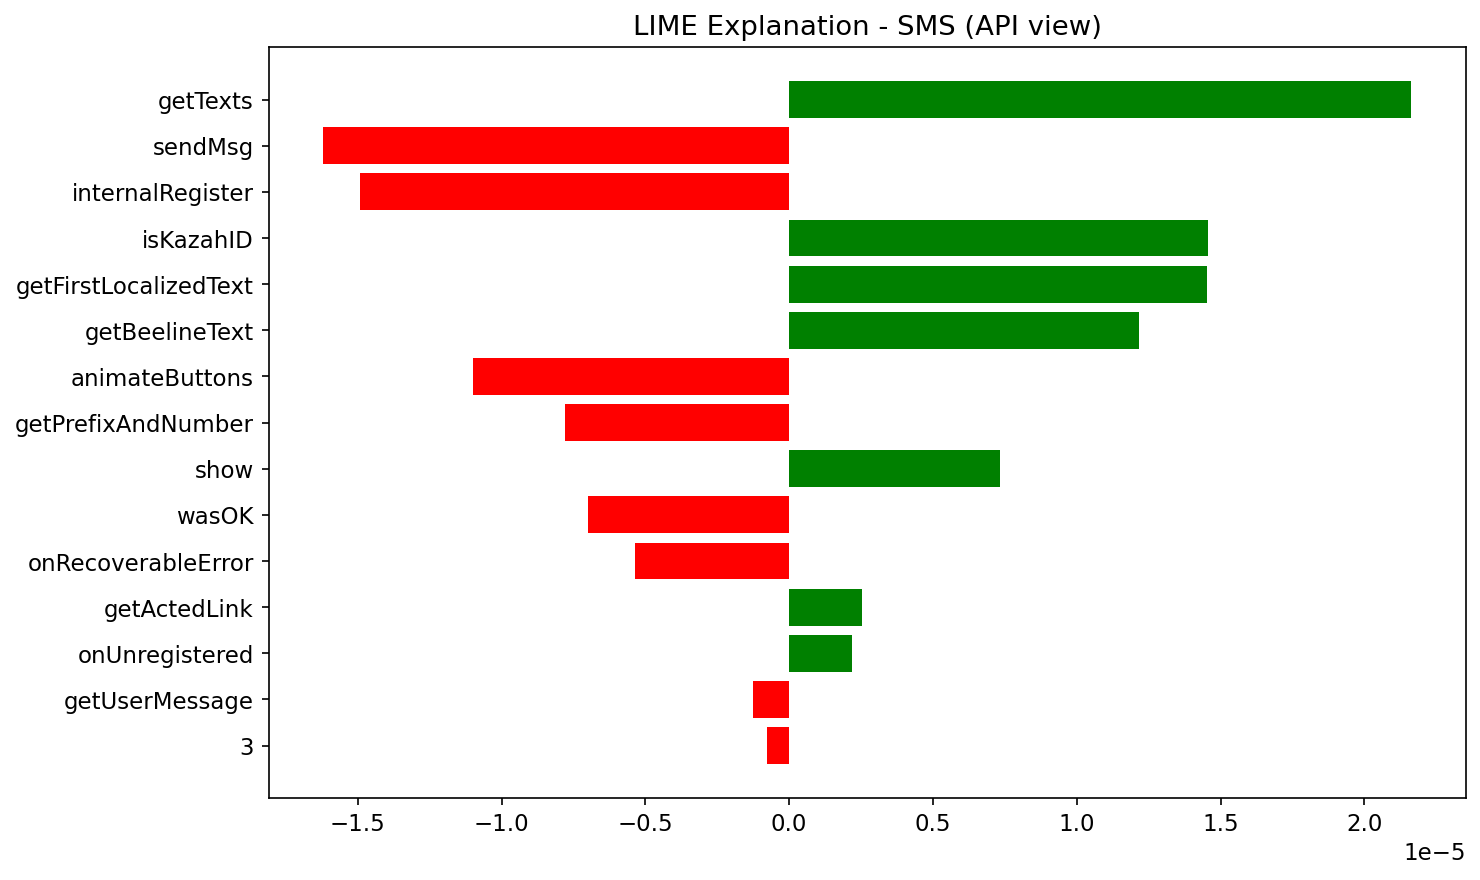

  Top contributing tokens in API:
    getTexts                       -> malware (+0.0000)
    sendMsg                        -> benign (-0.0000)
    internalRegister               -> benign (-0.0000)
    isKazahID                      -> malware (+0.0000)
    getFirstLocalizedText          -> malware (+0.0000)
    getBeelineText                 -> malware (+0.0000)
    animateButtons                 -> benign (-0.0000)
    getPrefixAndNumber             -> benign (-0.0000)
    show                           -> malware (+0.0000)
    wasOK                          -> benign (-0.0000)

Saving results...

Results saved to: /content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_results/results_summary.json

ALL DONE! FINAL RESULTS
  Binary Accuracy:  0.9863
  Binary F1:        0.9863
  Binary AUC:       0.9989
  Family Accuracy:  0.9648
  Family F1:        0.9646

  View Importance:
    PERM    : 0.2559
    API     : 0.2731
    INTENT  : 0.2614
    OPCODE  : 0.2096

  Results:  

In [ ]:
# ╔═══════════════════════════════════════════════════════════════╗
# ║  CELL 9: EXPLAINABILITY (LIME) AND SAVE RESULTS               ║
# ╚═══════════════════════════════════════════════════════════════╝

print("=" * 60)
print("Running LIME Explainability...")
print("=" * 60)

from lime.lime_text import LimeTextExplainer


def lime_predict_for_view(texts, view_name):
    """LIME-compatible prediction function for a specific view."""
    model.eval()
    all_probs = []

    for text in texts:
        encoding = tokenizer(
            text,
            max_length=Config.MAX_SEQ_LENGTH,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        empty_encoding = tokenizer(
            "",
            max_length=Config.MAX_SEQ_LENGTH,
            padding="max_length",
            return_tensors="pt",
        )

        batch = {}
        for view in Config.VIEWS:
            if view == view_name:
                batch[f"{view}_input_ids"] = encoding["input_ids"]
                batch[f"{view}_attention_mask"] = encoding["attention_mask"]
            else:
                batch[f"{view}_input_ids"] = empty_encoding["input_ids"]
                batch[f"{view}_attention_mask"] = empty_encoding["attention_mask"]

        batch["binary_label"] = torch.tensor([0])
        batch["family_label"] = torch.tensor([0])
        batch = {k: v.to(device) for k, v in batch.items()}

        with torch.no_grad():
            binary_logits, _ = model(batch)
            probs = F.softmax(binary_logits, dim=1).cpu().numpy()
            all_probs.append(probs[0])

    return np.array(all_probs)


# Run LIME on one sample per family
explainer = LimeTextExplainer(class_names=["Benign", "Malware"])
xai_dir = os.path.join(Config.OUTPUT_DIR, "explanations")
os.makedirs(xai_dir, exist_ok=True)

for family in Config.FAMILIES:
    family_samples = test_df[test_df["family"] == family]
    if len(family_samples) == 0:
        continue

    sample = family_samples.iloc[0]
    sample_idx = family_samples.index[0]

    # Find which view has the most content for this sample
    view_lengths = {v: len(sample[v].split()) if isinstance(sample[v], str) else 0 for v in Config.VIEWS}
    best_view = max(view_lengths, key=view_lengths.get)

    if view_lengths[best_view] == 0:
        print(f"  {family}: No content to explain, skipping.")
        continue

    print(f"\n  Explaining {family} sample (view: {best_view}, {view_lengths[best_view]} tokens)...")

    try:
        explanation = explainer.explain_instance(
            sample[best_view],
            lambda texts: lime_predict_for_view(texts, best_view),
            num_features=15,
            num_samples=200,
        )

        # Plot
        fig = explanation.as_pyplot_figure()
        fig.set_size_inches(10, 6)
        plt.title(f"LIME Explanation - {family} ({best_view} view)")
        plt.tight_layout()
        plt.savefig(os.path.join(xai_dir, f"lime_{family}_{best_view}.png"), bbox_inches="tight")
        plt.show()

        # Print top tokens
        print(f"  Top contributing tokens in {best_view}:")
        for feat, weight in explanation.as_list()[:10]:
            direction = "malware" if weight > 0 else "benign"
            print(f"    {feat:30s} -> {direction} ({weight:+.4f})")

    except Exception as e:
        print(f"  LIME failed for {family}: {e}")

# ── Save all results to JSON ──
print("\n" + "=" * 60)
print("Saving results...")
print("=" * 60)

results_summary = {
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "dataset": Config.DATASET_PATH,
    "dataset_size": len(df),
    "train_size": len(train_df),
    "val_size": len(val_df),
    "test_size": len(test_df),
    "binary_accuracy": float(accuracy_score(test_bin_labels, test_bin_preds)),
    "binary_f1": float(f1_score(test_bin_labels, test_bin_preds, average="weighted")),
    "binary_precision": float(precision_score(test_bin_labels, test_bin_preds, average="weighted")),
    "binary_recall": float(recall_score(test_bin_labels, test_bin_preds, average="weighted")),
    "binary_auc": float(binary_auc),
    "family_accuracy": float(accuracy_score(test_fam_labels, test_fam_preds)),
    "family_f1": float(f1_score(test_fam_labels, test_fam_preds, average="weighted")),
    "family_precision": float(precision_score(test_fam_labels, test_fam_preds, average="weighted")),
    "family_recall": float(recall_score(test_fam_labels, test_fam_preds, average="weighted")),
    "view_attention_global": {
        view: float(mean_attn[i]) for i, view in enumerate(Config.VIEWS)
    },
    "families": Config.FAMILIES,
    "epochs_trained": len(history["train_loss"]),
    "model_params": int(total_params),
    "config": {
        "bert_model": Config.BERT_MODEL,
        "max_seq_length": Config.MAX_SEQ_LENGTH,
        "fusion_heads": Config.FUSION_HEADS,
        "fusion_layers": Config.FUSION_LAYERS,
        "batch_size": Config.BATCH_SIZE,
        "learning_rate": Config.LEARNING_RATE,
        "dropout": Config.DROPOUT,
    },
}

with open(os.path.join(Config.OUTPUT_DIR, "results_summary.json"), "w") as f:
    json.dump(results_summary, f, indent=2)

print(f"\nResults saved to: {Config.OUTPUT_DIR}/results_summary.json")

# ── Final Summary ──
print("\n" + "=" * 60)
print("ALL DONE! FINAL RESULTS")
print("=" * 60)
print(f"  Binary Accuracy:  {results_summary['binary_accuracy']:.4f}")
print(f"  Binary F1:        {results_summary['binary_f1']:.4f}")
print(f"  Binary AUC:       {results_summary['binary_auc']:.4f}")
print(f"  Family Accuracy:  {results_summary['family_accuracy']:.4f}")
print(f"  Family F1:        {results_summary['family_f1']:.4f}")
print(f"\n  View Importance:")
for view, weight in results_summary['view_attention_global'].items():
    print(f"    {view:8s}: {weight:.4f}")
print(f"\n  Results:  {Config.OUTPUT_DIR}")
print(f"  Model:    {Config.MODEL_SAVE_DIR}")
print(f"  Plots:    {Config.OUTPUT_DIR}/*.png")
print(f"  LIME:     {Config.OUTPUT_DIR}/explanations/")


In [ ]:
import shutil
import os

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Create destination folders
os.makedirs("/content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_models", exist_ok=True)
os.makedirs("/content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_results", exist_ok=True)

# Copy models folder
src1 = "/content/malbert_xai_models"
dst1 = "/content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_models"

for f in os.listdir(src1):
    shutil.copy(os.path.join(src1, f), os.path.join(dst1, f))
    size = os.path.getsize(os.path.join(dst1, f)) / (1024*1024)
    print(f"  Copied: {f} ({size:.1f} MB) → malbert_xai_models/")

# Copy results folder (including subfolders like explanations/)
src2 = "/content/malbert_xai_results"
dst2 = "/content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_results"

for root, dirs, files in os.walk(src2):
    rel_path = os.path.relpath(root, src2)
    dest_dir = os.path.join(dst2, rel_path)
    os.makedirs(dest_dir, exist_ok=True)
    for f in files:
        shutil.copy(os.path.join(root, f), os.path.join(dest_dir, f))
        size = os.path.getsize(os.path.join(dest_dir, f)) / (1024*1024)
        print(f"  Copied: {rel_path}/{f} ({size:.2f} MB) → malbert_xai_results/")

print("\nDone! All files saved to Google Drive.")

ValueError: Mountpoint must not already contain files

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: Mountpoint must not already contain files

In [2]:
# ╔═══════════════════════════════════════════════════════════════╗
# ║  LOAD TRAINED MODEL AND TEST ON SINGLE APP                    ║
# ║  Run this in a FRESH Colab session — no retraining needed     ║
# ╚═══════════════════════════════════════════════════════════════╝

# ====================================================================
# STEP 0: IMPORTS
# ====================================================================
import os
import re
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import DistilBertTokenizerFast, DistilBertModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

warnings.filterwarnings("ignore")

# ====================================================================
# STEP 1: MOUNT DRIVE
# ====================================================================
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# ====================================================================
# STEP 2: SET YOUR PATHS (change these to match your Drive)
# ====================================================================
MODEL_PATH = "/content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_models/best_model.pt"
DATASET_PATH = "/content/drive/MyDrive/00 MalBert - Internship Project/00_final_dataset_multiview.csv"
OUTPUT_DIR = "/content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_results"

# Verify files exist
print("Checking files...")
print(f"  Model:   {'FOUND' if os.path.exists(MODEL_PATH) else 'NOT FOUND'} — {MODEL_PATH}")
print(f"  Dataset: {'FOUND' if os.path.exists(DATASET_PATH) else 'NOT FOUND'} — {DATASET_PATH}")

# ====================================================================
# STEP 3: CONFIG (must match training config exactly)
# ====================================================================
class Config:
    DATASET_PATH = DATASET_PATH
    OUTPUT_DIR = OUTPUT_DIR
    BERT_MODEL = "distilbert-base-uncased"
    MAX_SEQ_LENGTH = 512
    HIDDEN_DIM = 768
    FUSION_HEADS = 8
    FUSION_LAYERS = 2
    DROPOUT = 0.3
    SEED = 42
    VIEWS = ["PERM", "API", "INTENT", "OPCODE"]
    NUM_VIEWS = 4
    FAMILIES = []
    NUM_FAMILIES = 0

random.seed(Config.SEED)
np.random.seed(Config.SEED)
torch.manual_seed(Config.SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"  Device:  {device}")

# ====================================================================
# STEP 4: LOAD DATASET (needed for labels and test samples)
# ====================================================================
print("\nLoading dataset...")
df = pd.read_csv(Config.DATASET_PATH, encoding="latin-1", on_bad_lines="skip", engine="python")

# Handle merged format
if "text" in df.columns and "PERM" not in df.columns:
    def split_text_to_views(text):
        if not isinstance(text, str):
            return {"PERM": "", "API": "", "INTENT": "", "OPCODE": ""}
        views = {}
        perm_match = re.search(r"PERM:\s*(.*?)\s*API:", text, re.DOTALL)
        views["PERM"] = perm_match.group(1).strip() if perm_match else ""
        api_match = re.search(r"API:\s*(.*?)\s*INTENT:", text, re.DOTALL)
        views["API"] = api_match.group(1).strip() if api_match else ""
        intent_match = re.search(r"INTENT:\s*(.*?)\s*OPCODE:", text, re.DOTALL)
        views["INTENT"] = intent_match.group(1).strip() if intent_match else ""
        opcode_match = re.search(r"OPCODE:\s*(.*)", text, re.DOTALL)
        views["OPCODE"] = opcode_match.group(1).strip() if opcode_match else ""
        return views
    view_data = df["text"].apply(split_text_to_views).apply(pd.Series)
    df = pd.concat([df.drop(columns=["text"]), view_data], axis=1)

columns_to_drop = ["apk_size", "permission_count", "api_count", "opcode_count", "intent_count"]
df = df.drop(columns=[c for c in columns_to_drop if c in df.columns])
df = df.dropna(subset=["family"])
df["family"] = df["family"].replace("Benign3", "Benign")
known_families = ["Banking", "Riskware", "SMS", "Adware", "Benign"]
df = df[df["family"].isin(known_families)].reset_index(drop=True)
for view in Config.VIEWS:
    if view in df.columns:
        df[view] = df[view].fillna("")
    else:
        df[view] = ""

df["binary_label"] = (df["family"] != "Benign").astype(int)
label_encoder = LabelEncoder()
df["family_label"] = label_encoder.fit_transform(df["family"])
Config.FAMILIES = list(label_encoder.classes_)
Config.NUM_FAMILIES = len(Config.FAMILIES)

# Recreate the same test split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=Config.SEED, stratify=df["family_label"])
train_df, val_df = train_test_split(train_df, test_size=0.125, random_state=Config.SEED, stratify=train_df["family_label"])

print(f"Dataset: {len(df)} samples, Families: {Config.FAMILIES}")
print(f"Test set: {len(test_df)} samples")

# ====================================================================
# STEP 5: REBUILD MODEL ARCHITECTURE AND LOAD WEIGHTS
# ====================================================================
print("\nRebuilding model architecture...")

class CrossAttentionFusion(nn.Module):
    def __init__(self, hidden_dim, num_heads, num_layers, dropout=0.1):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=num_heads, dim_feedforward=hidden_dim * 4,
            dropout=dropout, activation="gelu", batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.view_position = nn.Parameter(torch.randn(1, Config.NUM_VIEWS, hidden_dim) * 0.02)
        self.attention_pool = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 4), nn.Tanh(), nn.Linear(hidden_dim // 4, 1),
        )
        self.layer_norm = nn.LayerNorm(hidden_dim)

    def forward(self, view_embeddings, return_attention=False):
        x = view_embeddings + self.view_position
        x = self.transformer(x)
        attn_scores = self.attention_pool(x)
        attn_weights = F.softmax(attn_scores, dim=1)
        fused = (x * attn_weights).sum(dim=1)
        fused = self.layer_norm(fused)
        if return_attention:
            return fused, attn_weights.squeeze(-1)
        return fused

class MalBERTXAI(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained(config.BERT_MODEL)
        self.view_projections = nn.ModuleDict({
            view: nn.Sequential(
                nn.Linear(config.HIDDEN_DIM, config.HIDDEN_DIM),
                nn.LayerNorm(config.HIDDEN_DIM), nn.GELU(), nn.Dropout(config.DROPOUT),
            ) for view in config.VIEWS
        })
        self.fusion = CrossAttentionFusion(
            hidden_dim=config.HIDDEN_DIM, num_heads=config.FUSION_HEADS,
            num_layers=config.FUSION_LAYERS, dropout=config.DROPOUT,
        )
        self.binary_classifier = nn.Sequential(
            nn.Linear(config.HIDDEN_DIM, config.HIDDEN_DIM // 2), nn.GELU(),
            nn.Dropout(config.DROPOUT), nn.Linear(config.HIDDEN_DIM // 2, 2),
        )
        self.family_classifier = nn.Sequential(
            nn.Linear(config.HIDDEN_DIM, config.HIDDEN_DIM // 2), nn.GELU(),
            nn.Dropout(config.DROPOUT), nn.Linear(config.HIDDEN_DIM // 2, config.NUM_FAMILIES),
        )

    def encode_view(self, input_ids, attention_mask, view_name):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        return self.view_projections[view_name](cls_embedding)

    def forward(self, batch, return_attention=False):
        view_embeddings = []
        for view in Config.VIEWS:
            emb = self.encode_view(batch[f"{view}_input_ids"], batch[f"{view}_attention_mask"], view)
            view_embeddings.append(emb)
        stacked = torch.stack(view_embeddings, dim=1)
        if return_attention:
            fused, attn_weights = self.fusion(stacked, return_attention=True)
        else:
            fused = self.fusion(stacked)
            attn_weights = None
        binary_logits = self.binary_classifier(fused)
        family_logits = self.family_classifier(fused)
        if return_attention:
            return binary_logits, family_logits, attn_weights
        return binary_logits, family_logits

# Build model and load trained weights
model = MalBERTXAI(Config).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print("Model loaded successfully from Google Drive!")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

# Load tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained(Config.BERT_MODEL)

print("\n" + "=" * 70)
print("  READY! Now run Cell 10 (single app demo) below.")
print("=" * 70)

Mounted at /content/drive
Checking files...
  Model:   FOUND — /content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_models/best_model.pt
  Dataset: FOUND — /content/drive/MyDrive/00 MalBert - Internship Project/00_final_dataset_multiview.csv
  Device:  cuda

Loading dataset...
Dataset: 15644 samples, Families: ['Adware', 'Banking', 'Benign', 'Riskware', 'SMS']
Test set: 3129 samples

Rebuilding model architecture...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully from Google Drive!
Parameters: 83,652,872


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


  READY! Now run Cell 10 (single app demo) below.


  MalBERT-XAI — SINGLE APP CLASSIFICATION DEMO

  Using test sample #11
  True label:  Malware (Riskware)

  Features extracted:
    Permissions : 38 tokens
    API Calls   : 2123 tokens
    Intents     : 22 tokens
    Opcodes     : 67 tokens

----------------------------------------------------------------------
  RUNNING MODEL INFERENCE...
----------------------------------------------------------------------

  PREDICTION RESULTS

  ⚠️  VERDICT: MALWARE (Confidence: 100.0%)
  🔍  Family:  Riskware

  Ground truth: Malware (Riskware)
  Prediction:   CORRECT ✓

  Binary Probabilities:
    Benign:    0.0%  
    Malware: 100.0%  █████████████████████████████

  Family Probabilities:
    Adware      :   0.0%  
    Banking     :   0.0%  
    Benign      :   0.0%  
    Riskware    : 100.0%  █████████████████████████████ ← predicted
    SMS         :   0.0%  

  View Importance (Cross-Attention Weights):
    #1 PERM    : 0.2703  █████████████
    #2 INTENT  : 0.2512  ████████████
    #3 API 

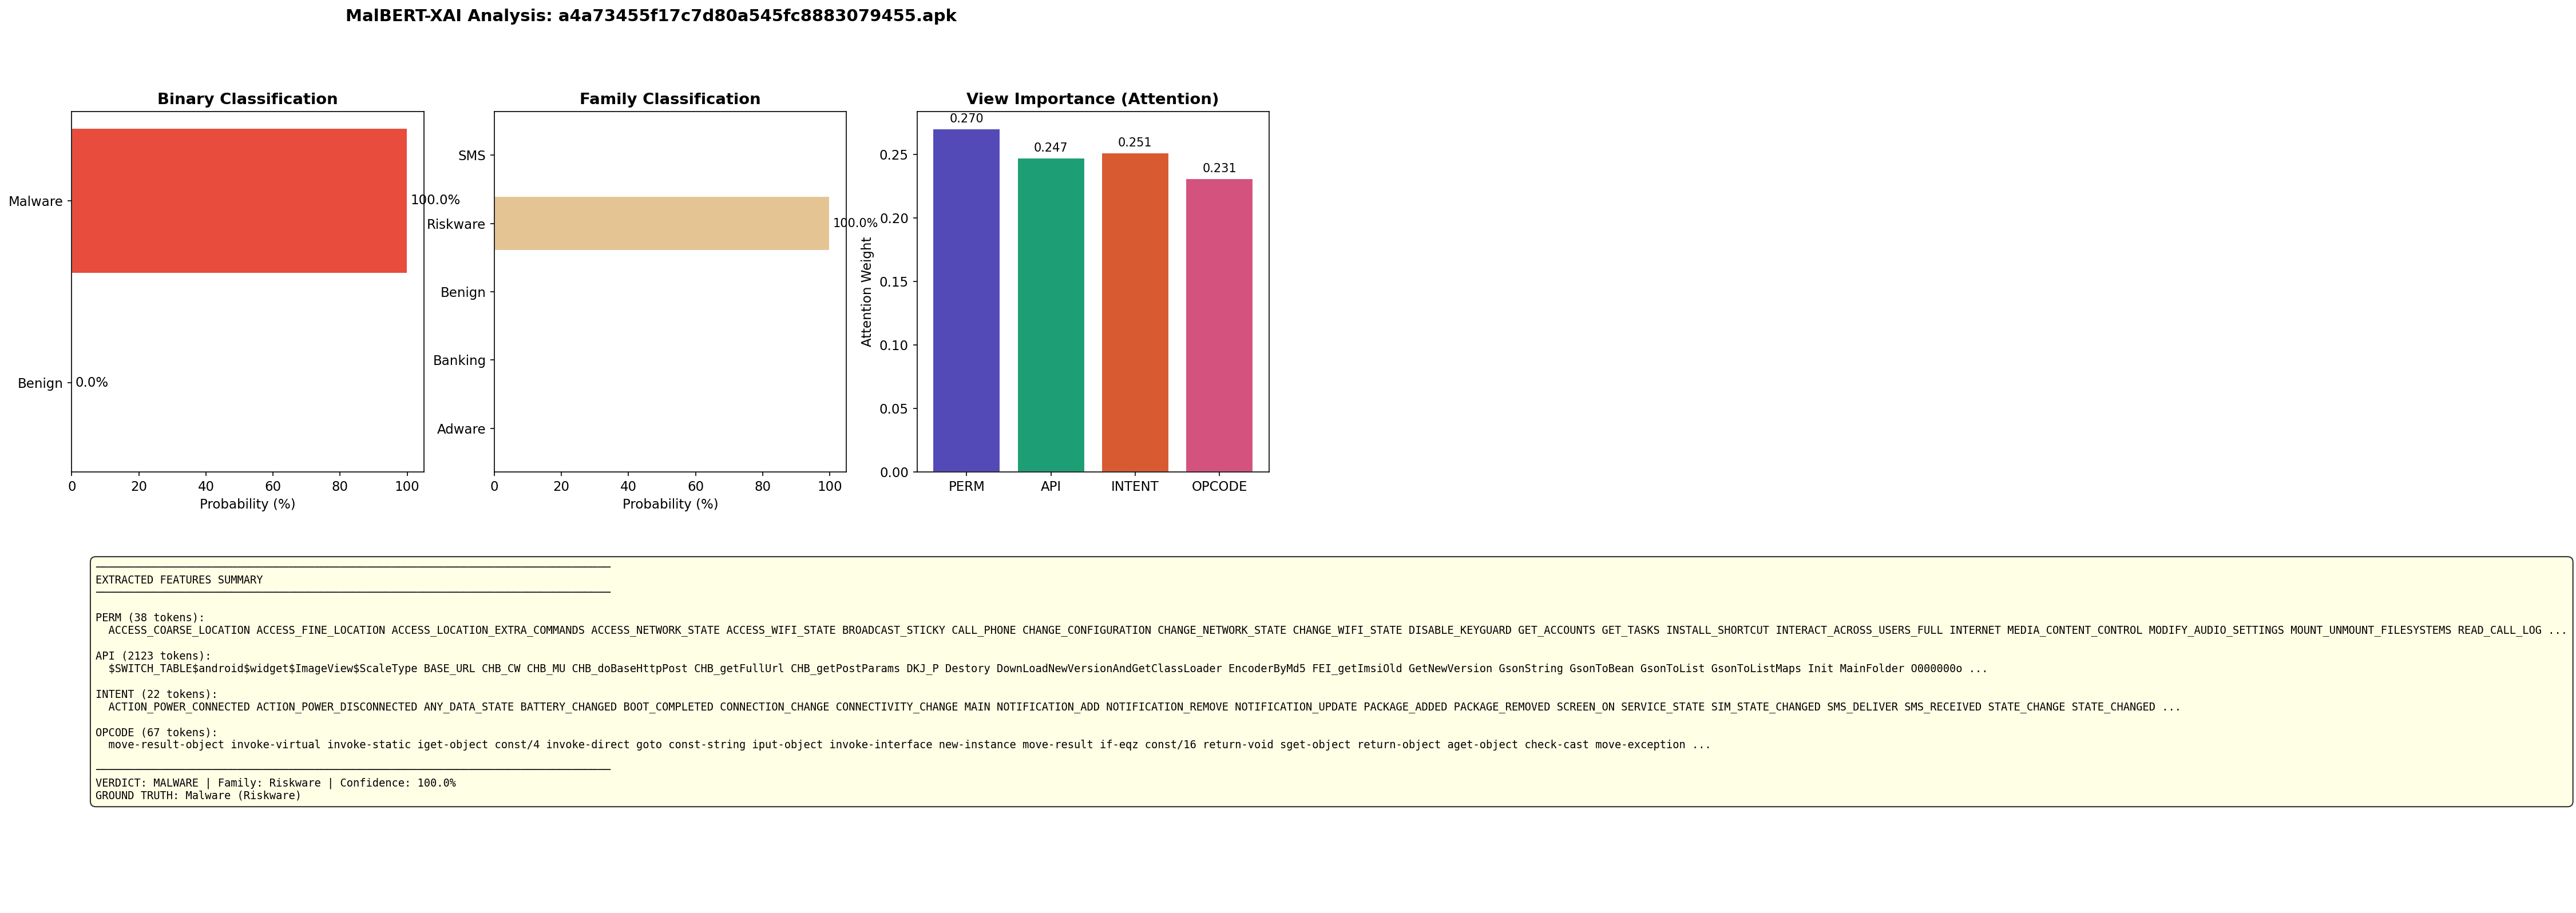


Saved: /content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_results/single_app_demo.png

  LIME TOKEN-LEVEL EXPLANATION

  Explaining most important view: PERM


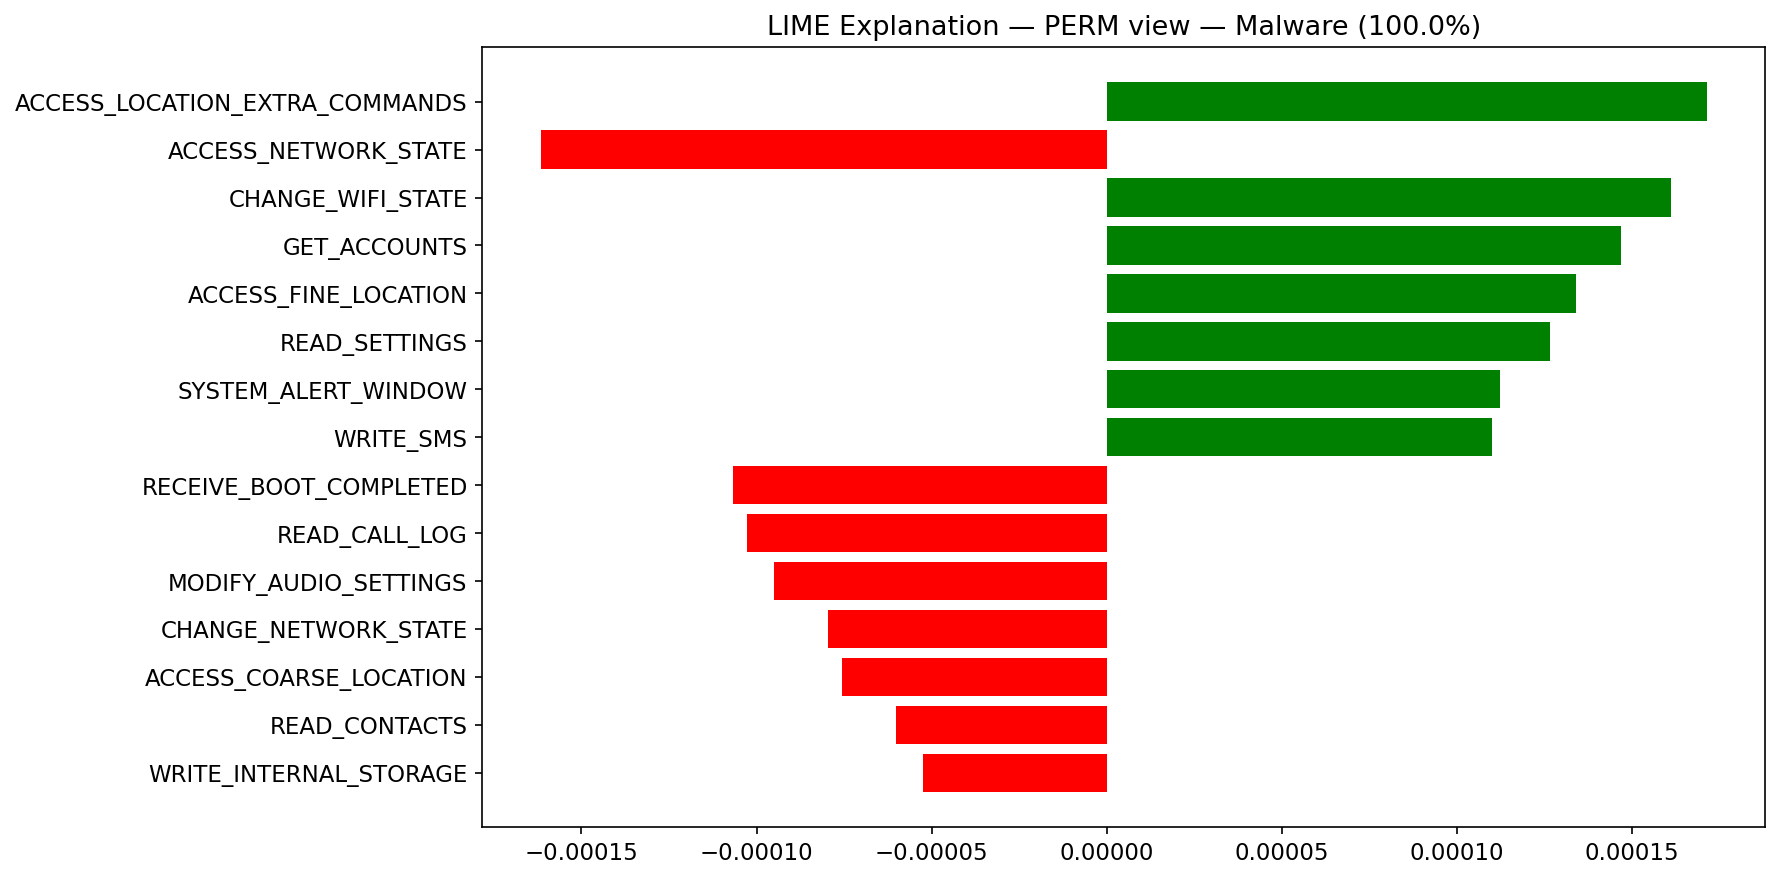


  Top tokens driving the prediction:
  Token                          Direction    Weight
  ──────────────────────────────────────────────────
  ACCESS_LOCATION_EXTRA_COMMANDS MALWARE     +0.0002
  ACCESS_NETWORK_STATE           BENIGN      -0.0002
  CHANGE_WIFI_STATE              MALWARE     +0.0002
  GET_ACCOUNTS                   MALWARE     +0.0001
  ACCESS_FINE_LOCATION           MALWARE     +0.0001
  READ_SETTINGS                  MALWARE     +0.0001
  SYSTEM_ALERT_WINDOW            MALWARE     +0.0001
  WRITE_SMS                      MALWARE     +0.0001
  RECEIVE_BOOT_COMPLETED         BENIGN      -0.0001
  READ_CALL_LOG                  BENIGN      -0.0001
  MODIFY_AUDIO_SETTINGS          BENIGN      -0.0001
  CHANGE_NETWORK_STATE           BENIGN      -0.0001
  ACCESS_COARSE_LOCATION         BENIGN      -0.0001
  READ_CONTACTS                  BENIGN      -0.0001
  WRITE_INTERNAL_STORAGE         BENIGN      -0.0001

  Saved: /content/drive/MyDrive/00 MalBert - Internship Proj

In [ ]:
# ╔═══════════════════════════════════════════════════════════════╗
# ║  CELL 10: SINGLE APP DEMO - CLASSIFY AND EXPLAIN            ║
# ║  Run this AFTER Cells 0-9 have completed training.          ║
# ╚═══════════════════════════════════════════════════════════════╝

# ====================================================================
# OPTION 1: Pick a sample from the test set (no APK needed)
# OPTION 2: Enter features manually for any new APK
# ====================================================================
# Set USE_TEST_SAMPLE = True  to demo on an existing test sample
# Set USE_TEST_SAMPLE = False to enter custom features manually
# ====================================================================

USE_TEST_SAMPLE = True
TEST_SAMPLE_INDEX = 11  # Change this to try different samples (0, 1, 2, ...)

# ── If USE_TEST_SAMPLE = False, paste your APK features here ──
CUSTOM_APP = {
    "name": "MyApp.apk",
    "PERM": "INTERNET SEND_SMS READ_PHONE_STATE ACCESS_NETWORK_STATE RECEIVE_BOOT_COMPLETED WRITE_EXTERNAL_STORAGE READ_CONTACTS",
    "API": "getDeviceId sendTextMessage getSubscriberId startActivity getSimSerialNumber",
    "INTENT": "BOOT_COMPLETED MAIN SMS_RECEIVED",
    "OPCODE": "invoke-virtual move-result-object const-string iget-object invoke-static",
}


# ====================================================================
# STEP 1: PREPARE THE SAMPLE
# ====================================================================

print("=" * 70)
print("  MalBERT-XAI — SINGLE APP CLASSIFICATION DEMO")
print("=" * 70)

if USE_TEST_SAMPLE:
    sample = test_df.iloc[TEST_SAMPLE_INDEX]
    app_name = sample.get("file_name", f"Test sample #{TEST_SAMPLE_INDEX}")
    true_family = sample["family"]
    true_binary = "Malware" if sample["binary_label"] == 1 else "Benign"
    perm_text = sample["PERM"] if isinstance(sample["PERM"], str) else ""
    api_text = sample["API"] if isinstance(sample["API"], str) else ""
    intent_text = sample["INTENT"] if isinstance(sample["INTENT"], str) else ""
    opcode_text = sample["OPCODE"] if isinstance(sample["OPCODE"], str) else ""
    print(f"\n  Using test sample #{TEST_SAMPLE_INDEX}")
    print(f"  True label:  {true_binary} ({true_family})")
else:
    app_name = CUSTOM_APP["name"]
    true_family = "Unknown"
    true_binary = "Unknown"
    perm_text = CUSTOM_APP["PERM"]
    api_text = CUSTOM_APP["API"]
    intent_text = CUSTOM_APP["INTENT"]
    opcode_text = CUSTOM_APP["OPCODE"]
    print(f"\n  Using custom app: {app_name}")

print(f"\n  Features extracted:")
print(f"    Permissions : {len(perm_text.split()) if perm_text else 0} tokens")
print(f"    API Calls   : {len(api_text.split()) if api_text else 0} tokens")
print(f"    Intents     : {len(intent_text.split()) if intent_text else 0} tokens")
print(f"    Opcodes     : {len(opcode_text.split()) if opcode_text else 0} tokens")


# ====================================================================
# STEP 2: TOKENIZE AND RUN THROUGH MODEL
# ====================================================================

print("\n" + "-" * 70)
print("  RUNNING MODEL INFERENCE...")
print("-" * 70)

model.eval()

# Tokenize each view
batch = {}
view_texts = {"PERM": perm_text, "API": api_text, "INTENT": intent_text, "OPCODE": opcode_text}

for view in Config.VIEWS:
    encoding = tokenizer(
        view_texts[view],
        max_length=Config.MAX_SEQ_LENGTH,
        padding="max_length",
        truncation=True,
        return_tensors="pt",
    )
    batch[f"{view}_input_ids"] = encoding["input_ids"].to(device)
    batch[f"{view}_attention_mask"] = encoding["attention_mask"].to(device)

batch["binary_label"] = torch.tensor([0]).to(device)
batch["family_label"] = torch.tensor([0]).to(device)

# Forward pass with attention
with torch.no_grad():
    binary_logits, family_logits, attn_weights = model(batch, return_attention=True)

# Get predictions
binary_probs = F.softmax(binary_logits, dim=1).cpu().numpy()[0]
family_probs = F.softmax(family_logits, dim=1).cpu().numpy()[0]
attn = attn_weights.cpu().numpy()[0]

binary_pred = "Malware" if binary_probs[1] > binary_probs[0] else "Benign"
family_pred = label_encoder.inverse_transform([family_probs.argmax()])[0]
confidence = max(binary_probs) * 100


# ====================================================================
# STEP 3: DISPLAY RESULTS
# ====================================================================

print("\n" + "=" * 70)
print("  PREDICTION RESULTS")
print("=" * 70)

if binary_pred == "Malware":
    print(f"\n  ⚠️  VERDICT: {binary_pred.upper()} (Confidence: {confidence:.1f}%)")
    print(f"  🔍  Family:  {family_pred}")
else:
    print(f"\n  ✅  VERDICT: {binary_pred.upper()} (Confidence: {confidence:.1f}%)")

if USE_TEST_SAMPLE:
    match = "CORRECT ✓" if binary_pred == true_binary else "INCORRECT ✗"
    print(f"\n  Ground truth: {true_binary} ({true_family})")
    print(f"  Prediction:   {match}")

print(f"\n  Binary Probabilities:")
print(f"    Benign:  {binary_probs[0]*100:5.1f}%  {'█' * int(binary_probs[0]*30)}")
print(f"    Malware: {binary_probs[1]*100:5.1f}%  {'█' * int(binary_probs[1]*30)}")

print(f"\n  Family Probabilities:")
for i, family_name in enumerate(label_encoder.classes_):
    bar = '█' * int(family_probs[i] * 30)
    marker = " ← predicted" if i == family_probs.argmax() else ""
    print(f"    {family_name:12s}: {family_probs[i]*100:5.1f}%  {bar}{marker}")


# ====================================================================
# STEP 4: VIEW IMPORTANCE (WHICH FEATURES MATTERED MOST)
# ====================================================================

print(f"\n  View Importance (Cross-Attention Weights):")
view_ranking = sorted(zip(Config.VIEWS, attn), key=lambda x: x[1], reverse=True)
for rank, (view, weight) in enumerate(view_ranking, 1):
    bar = '█' * int(weight * 50)
    print(f"    #{rank} {view:8s}: {weight:.4f}  {bar}")


# ====================================================================
# STEP 5: VISUALIZE EVERYTHING
# ====================================================================

fig = plt.figure(figsize=(18, 12))
fig.suptitle(f"MalBERT-XAI Analysis: {app_name[:50]}", fontsize=14, fontweight="bold", y=0.98)

# ── Plot A: Binary Prediction ──
ax1 = fig.add_subplot(2, 3, 1)
bar_colors = ["#2ecc71", "#e74c3c"]
bars = ax1.barh(["Benign", "Malware"], binary_probs * 100, color=bar_colors, edgecolor="white")
ax1.set_xlim(0, 105)
ax1.set_title("Binary Classification", fontweight="bold")
ax1.set_xlabel("Probability (%)")
for bar, prob in zip(bars, binary_probs):
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f"{prob*100:.1f}%", va="center", fontsize=11)

# ── Plot B: Family Probabilities ──
ax2 = fig.add_subplot(2, 3, 2)
family_colors = plt.cm.Set2(np.linspace(0, 1, Config.NUM_FAMILIES))
y_pos = np.arange(Config.NUM_FAMILIES)
bars = ax2.barh(y_pos, family_probs * 100, color=family_colors, edgecolor="white")
ax2.set_yticks(y_pos)
ax2.set_yticklabels(label_encoder.classes_)
ax2.set_xlim(0, 105)
ax2.set_title("Family Classification", fontweight="bold")
ax2.set_xlabel("Probability (%)")
for bar, prob in zip(bars, family_probs):
    if prob > 0.01:
        ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f"{prob*100:.1f}%", va="center", fontsize=10)

# ── Plot C: View Importance ──
ax3 = fig.add_subplot(2, 3, 3)
view_colors = ["#534AB7", "#1D9E75", "#D85A30", "#D4537E"]
bars = ax3.bar(Config.VIEWS, attn, color=view_colors, edgecolor="white")
ax3.set_title("View Importance (Attention)", fontweight="bold")
ax3.set_ylabel("Attention Weight")
for bar, weight in zip(bars, attn):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{weight:.3f}", ha="center", fontsize=10)

# ── Plot D: Feature Tokens Preview ──
ax4 = fig.add_subplot(2, 1, 2)
ax4.axis("off")

# Build feature summary text
text_lines = []
text_lines.append(f"{'─'*80}")
text_lines.append(f"EXTRACTED FEATURES SUMMARY")
text_lines.append(f"{'─'*80}")

for view in Config.VIEWS:
    tokens = view_texts[view].split()[:20]  # Show first 20 tokens
    token_str = " ".join(tokens)
    if len(view_texts[view].split()) > 20:
        token_str += " ..."
    text_lines.append(f"\n{view} ({len(view_texts[view].split())} tokens):")
    text_lines.append(f"  {token_str}")

text_lines.append(f"\n{'─'*80}")
verdict_line = f"VERDICT: {binary_pred.upper()} | Family: {family_pred} | Confidence: {confidence:.1f}%"
text_lines.append(verdict_line)
if USE_TEST_SAMPLE:
    text_lines.append(f"GROUND TRUTH: {true_binary} ({true_family})")

full_text = "\n".join(text_lines)
ax4.text(0.02, 0.95, full_text, transform=ax4.transAxes, fontsize=9,
         verticalalignment="top", fontfamily="monospace",
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", alpha=0.8))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(Config.OUTPUT_DIR, "single_app_demo.png"), bbox_inches="tight", dpi=150)
plt.show()
print(f"\nSaved: {Config.OUTPUT_DIR}/single_app_demo.png")


# ====================================================================
# STEP 6: LIME EXPLANATION FOR THIS SPECIFIC APP
# ====================================================================

print("\n" + "=" * 70)
print("  LIME TOKEN-LEVEL EXPLANATION")
print("=" * 70)

from lime.lime_text import LimeTextExplainer

# Find the most important view for this sample
top_view = view_ranking[0][0]
print(f"\n  Explaining most important view: {top_view}")

if view_texts[top_view].strip():

    def predict_single_view(texts):
        model.eval()
        all_probs = []
        for text in texts:
            enc = tokenizer(text, max_length=Config.MAX_SEQ_LENGTH,
                            padding="max_length", truncation=True, return_tensors="pt")
            empty_enc = tokenizer("", max_length=Config.MAX_SEQ_LENGTH,
                                  padding="max_length", return_tensors="pt")
            b = {}
            for v in Config.VIEWS:
                if v == top_view:
                    b[f"{v}_input_ids"] = enc["input_ids"].to(device)
                    b[f"{v}_attention_mask"] = enc["attention_mask"].to(device)
                else:
                    b[f"{v}_input_ids"] = empty_enc["input_ids"].to(device)
                    b[f"{v}_attention_mask"] = empty_enc["attention_mask"].to(device)
            b["binary_label"] = torch.tensor([0]).to(device)
            b["family_label"] = torch.tensor([0]).to(device)
            with torch.no_grad():
                logits, _ = model(b)
                probs = F.softmax(logits, dim=1).cpu().numpy()
                all_probs.append(probs[0])
        return np.array(all_probs)

    explainer = LimeTextExplainer(class_names=["Benign", "Malware"])
    explanation = explainer.explain_instance(
        view_texts[top_view],
        predict_single_view,
        num_features=15,
        num_samples=300,
    )

    # Plot LIME
    fig = explanation.as_pyplot_figure()
    fig.set_size_inches(12, 6)
    plt.title(f"LIME Explanation — {top_view} view — {binary_pred} ({confidence:.1f}%)", fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(Config.OUTPUT_DIR, "single_app_lime.png"), bbox_inches="tight", dpi=150)
    plt.show()

    print(f"\n  Top tokens driving the prediction:")
    print(f"  {'Token':<30s} {'Direction':<10s} {'Weight':>8s}")
    print(f"  {'─'*50}")
    for feat, weight in explanation.as_list()[:15]:
        direction = "MALWARE" if weight > 0 else "BENIGN"
        print(f"  {feat:<30s} {direction:<10s} {weight:>+8.4f}")

    print(f"\n  Saved: {Config.OUTPUT_DIR}/single_app_lime.png")

else:
    print(f"  {top_view} view is empty, cannot generate LIME explanation.")
    print(f"  Try a different sample by changing TEST_SAMPLE_INDEX above.")


# ====================================================================
# FINAL OUTPUT
# ====================================================================

print("\n" + "=" * 70)
print("  DEMO COMPLETE")
print("=" * 70)
print(f"""
  App:         {app_name[:60]}
  Verdict:     {binary_pred} ({confidence:.1f}% confidence)
  Family:      {family_pred} ({family_probs.max()*100:.1f}%)
  Top View:    {view_ranking[0][0]} (attention: {view_ranking[0][1]:.4f})
  Top Token:   {explanation.as_list()[0][0] if view_texts[top_view].strip() else 'N/A'}

  Plots saved:
    {Config.OUTPUT_DIR}/single_app_demo.png
    {Config.OUTPUT_DIR}/single_app_lime.png
""")

In [ ]:
# ╔═══════════════════════════════════════════════════════════════╗
# ║  ABLATION STUDY — View-Level Analysis                       ║
# ║  Run AFTER Cell 7 (model trained + test_loader ready)       ║
# ╚═══════════════════════════════════════════════════════════════╝

print("=" * 60)
print("ABLATION STUDY")
print("=" * 60)

ablation_results = {}

# ── Experiment configs ──
experiments = {
    "Full Model (all 4 views)":  ["PERM", "API", "INTENT", "OPCODE"],
    "PERM only":                 ["PERM"],
    "API only":                  ["API"],
    "INTENT only":               ["INTENT"],
    "OPCODE only":               ["OPCODE"],
    "PERM + API (2 views)":      ["PERM", "API"],
    "PERM + API + INTENT":       ["PERM", "API", "INTENT"],
    "No OPCODE":                 ["PERM", "API", "INTENT"],
    "No INTENT":                 ["PERM", "API", "OPCODE"],
    "No API":                    ["PERM", "INTENT", "OPCODE"],
    "No PERM":                   ["API", "INTENT", "OPCODE"],
}

model.eval()

for exp_name, active_views in experiments.items():
    print(f"\n  Running: {exp_name}...")

    all_bin_preds, all_bin_labels = [], []
    all_fam_preds, all_fam_labels = [], []

    with torch.no_grad():
        for batch in test_loader:

            # Create modified batch — empty out inactive views
            modified_batch = {}
            empty_enc = tokenizer(
                "", max_length=Config.MAX_SEQ_LENGTH,
                padding="max_length", return_tensors="pt"
            )

            for view in Config.VIEWS:
                if view in active_views:
                    modified_batch[f"{view}_input_ids"] = batch[f"{view}_input_ids"].to(device)
                    modified_batch[f"{view}_attention_mask"] = batch[f"{view}_attention_mask"].to(device)
                else:
                    # Replace inactive view with empty tokens
                    bs = batch[f"{view}_input_ids"].shape[0]
                    modified_batch[f"{view}_input_ids"] = empty_enc["input_ids"].expand(bs, -1).to(device)
                    modified_batch[f"{view}_attention_mask"] = empty_enc["attention_mask"].expand(bs, -1).to(device)

            modified_batch["binary_label"] = batch["binary_label"].to(device)
            modified_batch["family_label"] = batch["family_label"].to(device)

            binary_logits, family_logits = model(modified_batch)

            all_bin_preds.extend(binary_logits.argmax(dim=1).cpu().tolist())
            all_bin_labels.extend(batch["binary_label"].tolist())
            all_fam_preds.extend(family_logits.argmax(dim=1).cpu().tolist())
            all_fam_labels.extend(batch["family_label"].tolist())

    bin_f1 = f1_score(all_bin_labels, all_bin_preds, average="weighted")
    bin_acc = accuracy_score(all_bin_labels, all_bin_preds)
    fam_f1 = f1_score(all_fam_labels, all_fam_preds, average="weighted")
    fam_acc = accuracy_score(all_fam_labels, all_fam_preds)

    ablation_results[exp_name] = {
        "binary_f1": bin_f1,
        "binary_acc": bin_acc,
        "family_f1": fam_f1,
        "family_acc": fam_acc,
        "active_views": active_views
    }

    print(f"    Binary F1: {bin_f1:.4f} | Acc: {bin_acc:.4f}")
    print(f"    Family F1: {fam_f1:.4f} | Acc: {fam_acc:.4f}")

# ── Print Summary Table ──
print("\n\n" + "=" * 70)
print("ABLATION RESULTS SUMMARY TABLE")
print("=" * 70)
print(f"{'Experiment':<35s} {'Bin F1':>8s} {'Fam F1':>8s} {'Bin Acc':>8s} {'Fam Acc':>8s}")
print("-" * 70)

for name, r in ablation_results.items():
    marker = " ← FULL" if name == "Full Model (all 4 views)" else ""
    print(f"{name:<35s} {r['binary_f1']:>8.4f} {r['family_f1']:>8.4f} "
          f"{r['binary_acc']:>8.4f} {r['family_acc']:>8.4f}{marker}")

# ── Save to JSON ──
ablation_path = os.path.join(Config.OUTPUT_DIR, "ablation_results.json")
with open(ablation_path, "w") as f:
    json.dump(ablation_results, f, indent=2)
print(f"\nSaved: {ablation_path}")

ABLATION STUDY


NameError: name 'model' is not defined